In [1]:
# --- OBSERVATION SPACE MAPPING (29 Columns) ---

# 1. Physics State (0-20)
# ---------------------------------------------------------
# Indices 0-2: Angular Velocity (Body Frame)
#   0: AngVel_X (Roll Rate)
#   1: AngVel_Y (Pitch Rate)
#   2: AngVel_Z (Yaw Rate)

# Indices 3-6: Orientation (Quaternion - PyBullet Standard)
#   3: Quat_X
#   4: Quat_Y
#   5: Quat_Z
#   6: Quat_W  <-- SCALAR COMPONENT IS LAST

# Indices 7-9: Linear Velocity (Body Frame)
#   7: LinVel_X
#   8: LinVel_Y
#   9: LinVel_Z

# Indices 10-12: Global Position (Inertial Frame)
#   10: Pos_X
#   11: Pos_Y
#   12: Pos_Z

# Indices 13-16: Last Action (Control Inputs)
#   13: Act_Roll
#   14: Act_Pitch
#   15: Act_Yaw
#   16: Act_Thrust

# Indices 17-20: Auxiliary State
#   17: Aux_Thrust (Previous Thrust)
#   18: Aux_0 (Unused/Pad)
#   19: Aux_0 (Unused/Pad)
#   20: Aux_0 (Unused/Pad)

# 2. Context / Targets (21-28)
# ---------------------------------------------------------
# Indices 21-24: Next Target (Immediate Goal)
#   21: Rel_Dist_X
#   22: Rel_Dist_Y
#   23: Rel_Dist_Z
#   24: Rel_Yaw    <-- Non-zero in your data (Heading to target)

# Indices 25-28: Future Target (Lookahead)
#   25: Rel_Dist_X
#   26: Rel_Dist_Y
#   27: Rel_Dist_Z
#   28: Rel_Yaw

OBS_LABELS = [
    "AngVel_X", "AngVel_Y", "AngVel_Z",             # 0-2
    "Quat_X", "Quat_Y", "Quat_Z", "Quat_W",         # 3-6 (W is Last)
    "LinVel_X", "LinVel_Y", "LinVel_Z",             # 7-9
    "Pos_X", "Pos_Y", "Pos_Z",                      # 10-12
    "Act_Roll", "Act_Pitch", "Act_Yaw", "Act_Thr",  # 13-16
    "Aux_Thr", "Aux_Pad1", "Aux_Pad2", "Aux_Pad3",  # 17-20
    "T1_X", "T1_Y", "T1_Z", "T1_Yaw",               # 21-24
    "T2_X", "T2_Y", "T2_Z", "T2_Yaw"                # 25-28
]

## Metrics

defined metrics here

In [2]:
from metrics import * 

### Processing each run in the saved data

In [3]:
def process_file(filepath, condition, subj=None):
    try:
        data = np.load(filepath, allow_pickle=True)
    except: return []
    
    processed = []
    ep_keys = set([int(k.split('_')[1]) for k in data.keys() if k.startswith("ep_") and "obs" in k])
    for i in ep_keys:
        obs = data[f"ep_{i}_obs"]
        rew = data[f"ep_{i}_rew"]
        human_act = data[f"ep_{i}_human_act"]
        info = data[f"ep_{i}_info"]
        # --- PARSE STATE ---
        ang_vel = obs[:, 0:3]     # P, Q, R
        quat = obs[:, 3:7]        # X, Y, Z, W (Fixed Mapping)
        lin_vel = obs[:, 7:10]    # u, v, w
        pos = obs[:, 10:13]       # x, y, z
        
        # --- BASIC METRICS ---
        if f"ep_{i}_global_targets" in data:
            targets = data[f"ep_{i}_global_targets"]
        else: targets = np.array([])
        
        total_wps = len(targets)
        captured = calculate_waypoints_captured(rew)
        duration = data[f"ep_{i}_real_duration"] if f"ep_{i}_real_duration" in data else len(rew)/FPS

        is_done = data[f'ep_{i}_done'][-1]
        is_last_episode = (i == max(ep_keys))
        
        crashed = calculate_crashes(info, rew)
        completed = calculate_success(info)
        
        near_misses = calculate_near_misses(pos, targets, rew)
        saves = calculate_near_crashes(pos)
        flight_path_length = calculate_flight_distance(pos)
        flight_path_length_success = flight_path_length if completed else np.nan
        
        
        
        # --- BEHAVIOR ---
        bang_bang = calculate_volatility(human_act)
        cte_std, cte_avg = calculate_cte_stats(pos, targets, rew)
        entropy_val = calculate_control_entropy(human_act)
        max_g = calculate_max_g_force(lin_vel, ang_vel)
        energy_var = calculate_energy_variance(pos, lin_vel)
        pio_pitch = calculate_pio(human_act[:, 1]) # Pitch channel only
        pio_roll = calculate_pio(human_act[:, 0]) # Roll channel only
        inversion = calculate_inverted_time(quat)
        
        # --- TRUST / AI (GHOST ONLY) ---
        cosine, gap, ai_bang_bang, ai_jerk, latency, ai_pio_pitch, ai_pio_roll = np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
        
        if condition.lower() == "ghost" and f"ep_{i}_ai_act" in data:
            ai_act = data[f"ep_{i}_ai_act"]
            if np.any(ai_act):
                h_vec = human_act[:, :3]
                a_vec = ai_act[:, :3]
                
                cosine = calculate_trust_cosine(human_act, ai_act)
                gap = calculate_trust_intensity_gap(human_act, ai_act)
                latency = calculate_latency(human_act[:, 0], ai_act[:, 0])
                ai_bang_bang = calculate_volatility(ai_act)
                ai_pio_pitch = calculate_pio(ai_act[:, 1]) # Pitch channel only
                ai_pio_roll = calculate_pio(ai_act[:, 0]) # Roll channel only

        crashed = crashed or (is_done and completed==0 and not is_last_episode)
        success = is_done and completed and captured == 4
        processed.append({
            # Original
            "Episode_num": i+1,
            "Waypoints": captured,
            "Progress_rate": captured / 4,
            "Success": 1 if success else 0,
            "Crashed": 1 if crashed else 0,
            "Failures": 0 if success else 1,
            "Time_Total": duration,
            "Time_Success": duration if completed else np.nan,
            "Near_Misses": near_misses,
            "Near_Crashes": saves,
            "Flight_Path_Length": flight_path_length,
            "Flight_Path_Length_Success": flight_path_length_success, # NEW METRIC
            "Inversion": inversion,
            "Action_Vol_Bang": bang_bang,
            
            # New Advanced
            "CTE_Avg": cte_avg,
            "CTE_Std": cte_std,
            "Control_Entropy": entropy_val,
            "Max_G_Force": max_g,
            "Energy_Variance": energy_var,
            "PIO_Count_Pitch": pio_pitch,
            "PIO_Count_Roll": pio_roll,
            
            # Trust
            "Trust_Cosine": cosine,
            "Trust_Intensity_Gap": gap,
            "Trust_Latency_ms": latency,
            "AI_Vol_Bang": ai_bang_bang,
            "AI_PIO_Pitch": ai_pio_pitch,
            "AI_PIO_Roll": ai_pio_roll

        })
        
    return processed



In [4]:
import numpy as np
import pandas as pd
import os
import glob
from scipy.stats import entropy
from scipy.signal import correlate

# --- CONFIGURATION ---
MANIFEST_PATH = "flight_data/experiment_manifest.csv"
FPS = 60.0  # Physics rate (Verified)
G = 9.81    # Gravity
NEAR_MISS_RADIUS = 10.0
CAPTURE_RADIUS = 4.0



manifest = pd.read_csv(MANIFEST_PATH) if os.path.exists(MANIFEST_PATH) else None

all_data = []
print("Processing sessions...")

for _, row in manifest.iterrows():
    subj = row['Subject_ID']
    sess = row['Session']
        
    for t_col, f_col in [('Task_1', 'Folder_1'), ('Task_2', 'Folder_2'), ('Task_3', 'Folder_3')]:
        if t_col not in row or pd.isna(row[f_col]): continue
        folder = row[f_col]
        if not os.path.exists(folder): continue
        
        name = str(row[t_col]).lower()
        cond = "Alone"
        if sess == 1:
            if "arrow" in name: cond = "Arrow"
            if "ghost" in name: cond = "Ghost-S1"
        else:
            if "task_ghost_fixed_airl" in name: cond = "Ghost-S2"
            if "task_ghost_adaptive_airl" in name: cond = "Ghost-S2-adaptive"
        
        files = glob.glob(os.path.join(folder, "*.npz"))
        if not files: continue
        files.sort(key=os.path.getmtime, reverse=True)

        results = process_file(files[0], cond, subj=subj)
        for res in results:
            res['Subject'] = subj
            res['Session'] = sess
            res['Condition'] = cond

            all_data.append(res)
            
df = pd.DataFrame(all_data)
if not df.empty:
    df.to_csv("results/metrics_per_flight.csv", index=False)
    print("Saved 'results/metrics_per_flight.csv'")
    
    # --- UPDATED SUMMARY COLUMNS (ALL METRICS INCLUDED) ---
    cols = {
        # Performance,
        "Episode_num": "max",
        "Waypoints": "sum",
        "Progress_rate": ["mean", "std"],
        "Crashed": "sum",
        "Success": "sum",
        "Failures": "sum",
        "Time_Total": "mean",
        "Time_Success": "mean",
        "Near_Misses": "sum",
        "Near_Crashes": "sum",
        "Flight_Path_Length": "mean",
        "Flight_Path_Length_Success": "mean", # NEW METRIC
        "Inversion": "mean",
        "Action_Vol_Bang": "mean",
        
        # New Advanced
        "CTE_Avg": "mean",
        "CTE_Std": "mean",
        "Control_Entropy": "mean",
        "Max_G_Force": "mean",
        "Energy_Variance": "mean",
        "PIO_Count_Pitch": "mean",
        "PIO_Count_Roll": "mean",
        
        # Trust
        "Trust_Cosine": "mean",
        "Trust_Intensity_Gap": "mean",
        "Trust_Latency_ms": "mean",
        "AI_Vol_Bang": "mean",
        "AI_PIO_Pitch": "mean",
        "AI_PIO_Roll": "mean"
    }

    valid_agg = {k: v for k, v in cols.items() if k in df.columns}
    
    # Group by Subject (and Session if you want separate points per session)
    # Note: If you want to see the shift *per condition*, we must aggregate by Subject+Condition first
    # But for CLUSTERING the Human, we usually aggregate everything or cluster the Subject-Condition pairs.
    # Let's aggregate by Subject+Session to classify the "Pilot's Day".
    df_subjects = df.groupby(["Subject", "Session", "Condition"]).agg(valid_agg)
    df_subjects.columns = ['_'.join(col).strip('_') for col in df_subjects.columns]
    
    # 3. Now reset the index to bring Subject, Session, Condition back as columns
    df_subjects = df_subjects.reset_index()
    df_subjects['Progress_rate_std'] = df_subjects['Progress_rate_std'].fillna(0.0)
    print("\n--- EXPERIMENT SUMMARY ---")
    # summary = df.groupby("Condition")[cols].mean().round(2)
    # print(df_subjects)
    df_subjects.to_csv("results/metrics_summary_per_task.csv", index=False)
    # df.groupby("Condition")[cols].mean().to_csv("metrics_summary.csv")



Processing sessions...


/Users/mannan/pyflyt-env/lib/python3.9/site-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


Saved 'results/metrics_per_flight.csv'

--- EXPERIMENT SUMMARY ---


In [5]:
sum(df_subjects["Episode_num_max"] == (df_subjects["Failures_sum"] + df_subjects["Success_sum"]))

159

#### looking at metric redundancy before clustering

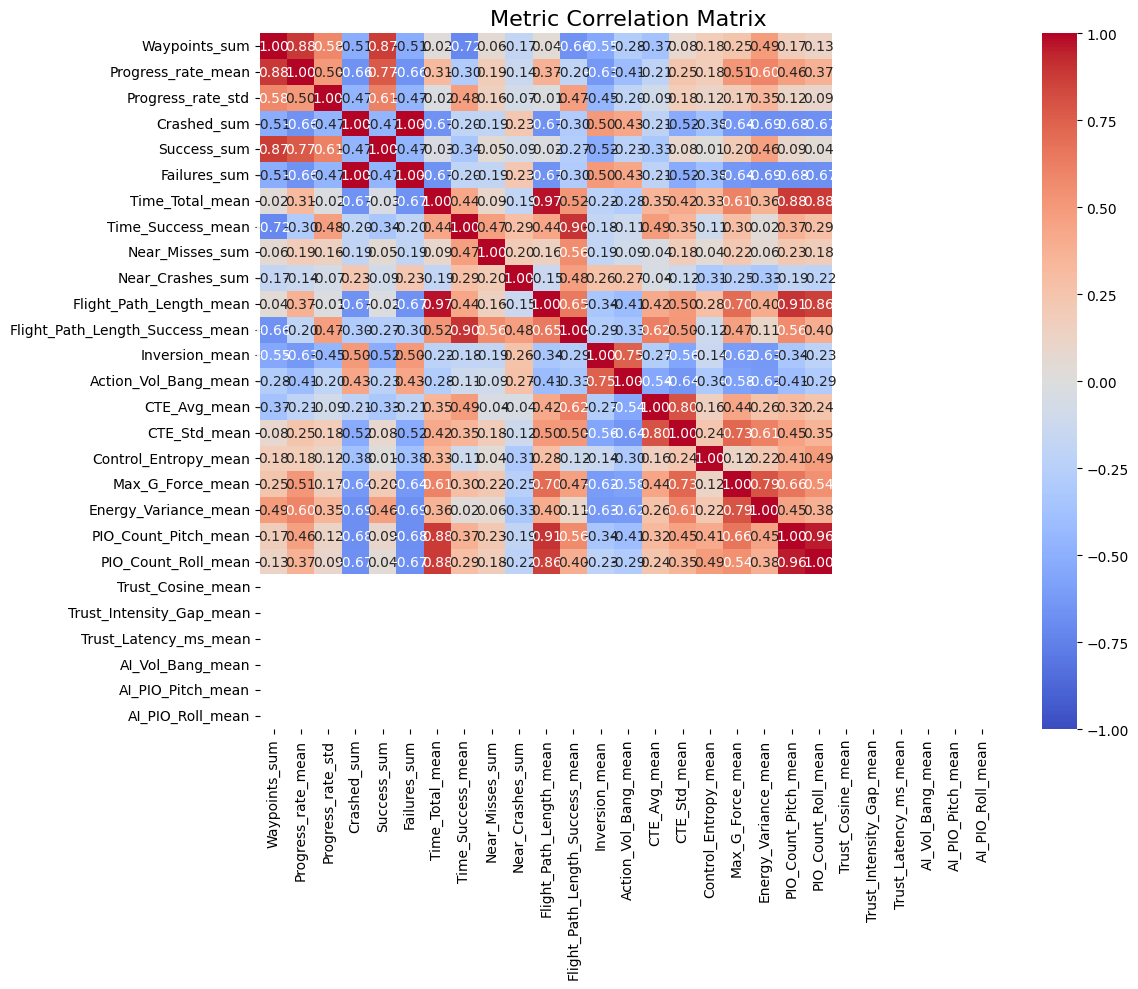


--- Highly Correlated Pairs (> 0.8) ---
Waypoints_sum <--> Progress_rate_mean: 0.88
Waypoints_sum <--> Success_sum: 0.87
Crashed_sum <--> Failures_sum: 1.00
Time_Total_mean <--> Flight_Path_Length_mean: 0.97
Time_Total_mean <--> PIO_Count_Pitch_mean: 0.88
Time_Total_mean <--> PIO_Count_Roll_mean: 0.88
Time_Success_mean <--> Flight_Path_Length_Success_mean: 0.90
Flight_Path_Length_mean <--> PIO_Count_Pitch_mean: 0.91
Flight_Path_Length_mean <--> PIO_Count_Roll_mean: 0.86
PIO_Count_Pitch_mean <--> PIO_Count_Roll_mean: 0.96


[('Waypoints_sum', 'Progress_rate_mean', np.float64(0.8843239429099398)),
 ('Waypoints_sum', 'Success_sum', np.float64(0.8700813008130078)),
 ('Crashed_sum', 'Failures_sum', np.float64(1.0)),
 ('Time_Total_mean',
  'Flight_Path_Length_mean',
  np.float64(0.9689519421124813)),
 ('Time_Total_mean', 'PIO_Count_Pitch_mean', np.float64(0.8826117457564067)),
 ('Time_Total_mean', 'PIO_Count_Roll_mean', np.float64(0.8809325541414958)),
 ('Time_Success_mean',
  'Flight_Path_Length_Success_mean',
  np.float64(0.901241590643553)),
 ('Flight_Path_Length_mean',
  'PIO_Count_Pitch_mean',
  np.float64(0.9061906969021479)),
 ('Flight_Path_Length_mean',
  'PIO_Count_Roll_mean',
  np.float64(0.8647092968848019)),
 ('PIO_Count_Pitch_mean',
  'PIO_Count_Roll_mean',
  np.float64(0.9584132733463552))]

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_metric_redundancy(df, metrics, threshold=0.85):
    """
    Calculates the correlation matrix and identifies redundant pairs.
    """
    # 1. Filter Data
    # Only use numeric columns that are in your list
    valid_metrics = [m for m in metrics if m in df.columns]
    corr_matrix = df[valid_metrics].corr()
    
    # 2. Visualize with Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
    plt.title("Metric Correlation Matrix", size=16)
    plt.tight_layout()
    plt.show()
    
    # 3. Identify High Correlations (The "Redundancy Report")
    print(f"\n--- Highly Correlated Pairs (> {threshold}) ---")
    
    # Iterate through the upper triangle of the matrix only
    # (Because the matrix is symmetrical, and we don't compare a variable to itself)
    redundant_pairs = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            val = corr_matrix.iloc[i, j]
            if abs(val) >= threshold:
                pair = (cols[i], cols[j], val)
                redundant_pairs.append(pair)
                print(f"{pair[0]} <--> {pair[1]}: {val:.2f}")

    if not redundant_pairs:
        print("No redundant metrics found.")
        
    return redundant_pairs

# Example Usage:
# all_metrics = positive_metrics + negative_metrics

metrics = [
    "Waypoints_sum",
    "Progress_rate_mean",
    "Progress_rate_std",
    "Crashed_sum",
    "Success_sum",
    "Failures_sum",
    "Time_Total_mean",
    "Time_Success_mean",
    "Near_Misses_sum",
    "Near_Crashes_sum",
    "Flight_Path_Length_mean",
    "Flight_Path_Length_Success_mean",
    "Inversion_mean",
    "Action_Vol_Bang_mean",
    "CTE_Avg_mean",
    "CTE_Std_mean",
    "Control_Entropy_mean",
    "Max_G_Force_mean",
    "Energy_Variance_mean",
    "PIO_Count_Pitch_mean",
    "PIO_Count_Roll_mean",
    "Trust_Cosine_mean",
    "Trust_Intensity_Gap_mean",
    "Trust_Latency_ms_mean",
    "AI_Vol_Bang_mean",
    "AI_PIO_Pitch_mean",
    "AI_PIO_Roll_mean",
]

alone_task_subjects = df_subjects[df_subjects["Condition"] == "Alone"]
analyze_metric_redundancy(alone_task_subjects, metrics, threshold=0.8)

## Cluster participants based off of performance

In [7]:
metric_labels_pub = {
    "Waypoints_sum": "Waypoints",
    "Progress_rate_mean": "Progress Rate",
    "Progress_rate_std": "Progress Rate SD",
    "Crashed_sum": "Crashes",
    "Success_sum": "Successes",
    "Failures_sum": "Failures",
    "Time_Total_mean": "Total Time",
    "Time_Success_mean": "Time to Success",
    "Near_Misses_sum": "Near Misses",
    "Near_Crashes_sum": "Near Crashes",
    "Flight_Path_Length_mean": "Path Length",
    "Flight_Path_Length_Success_mean": "Path Length (Success)",
    "Inversion_mean": "Inversions",
    "Action_Vol_Bang_mean": "Control Volatility",
    "CTE_Avg_mean": "CTE Mean",
    "CTE_Std_mean": "CTE SD",
    "Control_Entropy_mean": "Control Entropy",
    "Max_G_Force_mean": "Max G",
    "Energy_Variance_mean": "Energy Variance",
    "PIO_Count_Pitch_mean": "PIO Pitch",
    "PIO_Count_Roll_mean": "PIO Roll",
    "Trust_Cosine_mean": "Trust Cosine",
    "Trust_Intensity_Gap_mean": "Trust Intensity Gap",
    "Trust_Latency_ms_mean": "Trust Latency (ms)",
    "AI_Vol_Bang_mean": "AI Control Volatility",
    "AI_PIO_Pitch_mean": "AI PIO Pitch",
    "AI_PIO_Roll_mean": "AI PIO Roll",
}

In [34]:
POSITIVE_METRICS = ["Waypoints_sum", "Progress_rate_mean", "Success_sum",]
NEGATIVE_METRICS = ["Crashed_sum",
    # "Near_Misses_sum",
    # "Near_Crashes_sum",
    "Inversion_mean",
    "Action_Vol_Bang_mean",
    # "CTE_Avg_mean",
    "CTE_Std_mean",
    "Max_G_Force_mean",
    "Control_Entropy_mean"
    # "PIO_Count_Pitch_mean",
    # "PIO_Count_Roll_mean",
    ]

TRUST_METRICS = ["Trust_Cosine_mean", "Trust_Intensity_Gap_mean", "Trust_Latency_ms_mean", "AI_Vol_Bang_mean", "AI_PIO_Pitch_mean", "AI_PIO_Roll_mean"]

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from math import pi
from sklearn.metrics import silhouette_score
import os



def plot_split_radar_profiles(df_centers, positive_metrics, negative_metrics, title="Pilot Skill Profiles"):
    """
    Visualizes cluster profiles with two separate radar charts:
    Left: Positive Metrics (Performance)
    Right: Negative Metrics (Risks/Errors)
    """
    # 1. Normalize the data (0 to 1) for fair comparison
    # We fit on the full dataset so the relative scale is preserved
    scaler = MinMaxScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_centers), columns=df_centers.columns, index=df_centers.index)
    
    # 2. Filter lists to ensure we only plot columns that actually exist in the dataframe
    pos_feats = [m for m in positive_metrics if m in df_scaled.columns]
    neg_feats = [m for m in negative_metrics if m in df_scaled.columns]

    # Setup the figure
    fig = plt.figure(figsize=(18, 8))
    colors = ['#e74c3c', '#f1c40f', '#2ecc71', '#3498db'] # Red, Yellow, Green, Blue
    
    # --- Helper Function to Draw One Radar Chart ---
    def draw_radar(ax, features, subplot_title):
        if not features:
            ax.text(0.5, 0.5, "No Data", ha='center')
            return

        # Calculate Angles
        N = len(features)
        angles = [n / float(N) * 2 * pi for n in range(N)]
        angles += angles[:1] # Close the loop
        
        # Setup Axis
        plt.sca(ax)
        plt.xticks(angles[:-1], features, size=10)
        ax.set_rlabel_position(0)
        plt.yticks([0.25, 0.5, 0.75], ["25%", "50%", "75%"], color="grey", size=8)
        plt.ylim(0, 1)
        ax.set_title(subplot_title, size=14, y=1.1)

        # Plot each Cluster
        for i, (idx, row) in enumerate(df_scaled.iterrows()):
            values = row[features].values.flatten().tolist()
            values += values[:1] # Close the loop
            
            cluster_name = f"Cluster {idx}"
            ax.plot(angles, values, linewidth=2, linestyle='solid', label=cluster_name, color=colors[i % len(colors)])
            ax.fill(angles, values, color=colors[i % len(colors)], alpha=0.1)

    # --- Plot 1: Positive Metrics ---
    ax1 = plt.subplot(121, polar=True)
    draw_radar(ax1, pos_feats, "Performance Profile (Higher is Better)")
    
    # --- Plot 2: Negative Metrics ---
    ax2 = plt.subplot(122, polar=True)
    draw_radar(ax2, neg_feats, "Risk/Error Profile (Lower is Better)")

    # Legend & Layout
    # We only need one legend since the colors are consistent
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.05), ncol=len(df_centers))
    
    plt.suptitle(title, size=20, y=0.98)
    plt.tight_layout()
    plt.show()

def plot_radar_profiles(df_centers, features, title="Pilot Skill Profiles"):
    """ Visualizes the 'Fingerprint' of each Cluster """
    # Normalize to 0-1 for the chart
    scaler = MinMaxScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_centers), columns=features)
    df_scaled['Cluster'] = df_centers.index
    
    categories = features
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, polar=True)
    
    colors = ['#e74c3c', '#f1c40f', '#2ecc71', '#3498db'] # Red, Yellow, Green, Blue
    
    for i, row in df_scaled.iterrows():
        values = row[features].values.flatten().tolist()
        values += values[:1]
        
        cluster_name = str(row['Cluster'])
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=cluster_name, color=colors[i % len(colors)])
        ax.fill(angles, values, color=colors[i % len(colors)], alpha=0.1)
        
    plt.xticks(angles[:-1], categories, size=10)
    ax.set_rlabel_position(0)
    plt.yticks([0.25, 0.5, 0.75], ["25%", "50%", "75%"], color="grey", size=8)
    plt.ylim(0, 1)
    plt.title(title, size=16, y=1.05)
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.tight_layout()
    plt.show()

def find_optimal_clusters(df, max_k=10, features=POSITIVE_METRICS + NEGATIVE_METRICS):
    
    X = df[features]

    # Normalize
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    inertia = []
    silhouette_avgs = []
    k_range = range(2, max_k + 1)

    print(f"Analyzing Clusters for {len(df)} Subjects...")

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        
        inertia.append(kmeans.inertia_)
        silhouette_avgs.append(silhouette_score(X, kmeans.labels_))
        print(f"k={k}: Silhouette={silhouette_avgs[-1]:.3f}")

    # --- PLOTTING ---
    fig, ax1 = plt.subplots(figsize=(6, 4))

    # Plot 1: Elbow Curve (Inertia)
    ax1.plot(k_range, inertia, 'bo-')
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Inertia (Sum of Squared Distances)', color='blue')
    # ax1.set_title('Elbow Method')
    # ax1.grid(True)

    # Plot 2: Silhouette Score
    ax2 = ax1.twinx()
    ax2.plot(k_range, silhouette_avgs, 'ro-')
    ax2.set_xlabel('Number of Clusters (k)')
    ax2.set_ylabel('Silhouette Score (Higher is Better)', color='red')
    # ax2.set_title('Silhouette Analysis')
    # ax2.grid(True)
    plt.title('Elbow Method vs. Silhouette Score')
    plt.tight_layout()
    plt.savefig("results/cluster_optimization.png")
    plt.show()
    
    



In [36]:
alone_task_subjects = df_subjects[(df_subjects['Condition'] == 'Alone') & (df_subjects['Session'] == 1)]
alone_task_subjects.isna().sum()

Subject                             0
Session                             0
Condition                           0
Episode_num_max                     0
Waypoints_sum                       0
Progress_rate_mean                  0
Progress_rate_std                   0
Crashed_sum                         0
Success_sum                         0
Failures_sum                        0
Time_Total_mean                     0
Time_Success_mean                  23
Near_Misses_sum                     0
Near_Crashes_sum                    0
Flight_Path_Length_mean             0
Flight_Path_Length_Success_mean    23
Inversion_mean                      0
Action_Vol_Bang_mean                0
CTE_Avg_mean                        0
CTE_Std_mean                        0
Control_Entropy_mean                0
Max_G_Force_mean                    0
Energy_Variance_mean                0
PIO_Count_Pitch_mean                0
PIO_Count_Roll_mean                 0
Trust_Cosine_mean                  30
Trust_Intens

Analyzing Clusters for 30 Subjects...
k=2: Silhouette=0.322
k=3: Silhouette=0.322
k=4: Silhouette=0.330
k=5: Silhouette=0.228
k=6: Silhouette=0.235
k=7: Silhouette=0.260
k=8: Silhouette=0.256
k=9: Silhouette=0.231
k=10: Silhouette=0.247


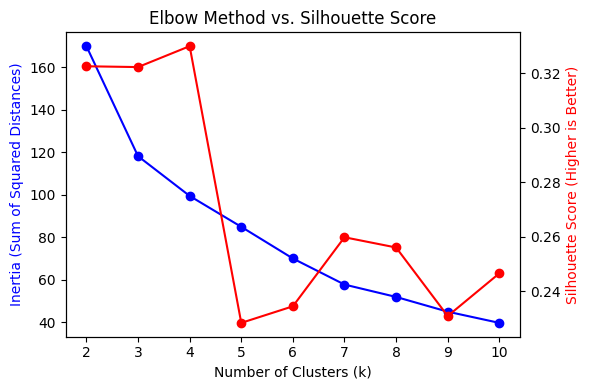

In [37]:
find_optimal_clusters(alone_task_subjects)

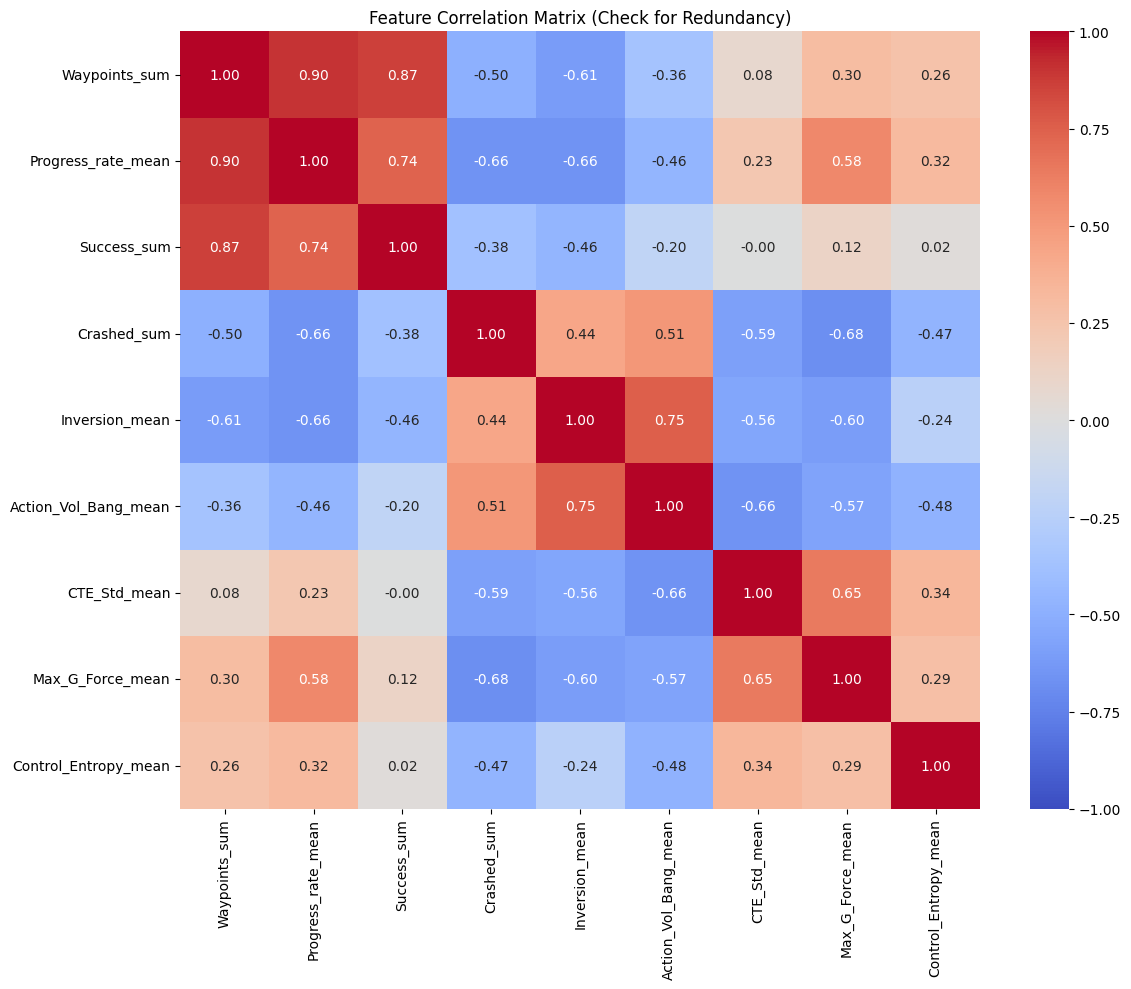

In [38]:

corr_matrix = alone_task_subjects[POSITIVE_METRICS+NEGATIVE_METRICS].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix (Check for Redundancy)")
plt.tight_layout()
plt.show()

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans

# --- CONFIG ---
FEATURES = POSITIVE_METRICS + NEGATIVE_METRICS
N_CLUSTERS = 3  # Based on your elbow analysis (likely 3)

def perform_skill_analysis(df):
    """
    1. Trains Clustering on Alone (Task 1) data.
    2. Projects this standard onto Arrow/Ghost data.
    3. Returns df with a new 'Skill_Cluster' column.
    """
    print(f"--- Starting Skill Analysis on {len(df)} rows ---")
    
    # 1. Filter for Training Data (Alone Task Only)
    # We assume 'Condition' column exists. Adjust if it's named 'Task_Type' etc.
    train_mask = df['Condition'] == 'Alone'
    Alone_df = df[train_mask].copy()
    
    # 2. Preprocessing (Standardization)
    # K-Means needs Mean=0, Std=1 to treat all features equally
    scaler = StandardScaler()
    X_train = Alone_df[FEATURES].values
    
    # FIT the scaler only on Alone data
    scaler.fit(X_train)
    
    # 3. Train K-Means
    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
    kmeans.fit(scaler.transform(X_train))
    
    # 4. Project (Predict) on ALL Data (Alone, Arrow, Ghost)
    # This applies the "Alone Standard" to everyone.
    X_all = df[FEATURES].values
    X_all_scaled = scaler.transform(X_all)
    
    df['Skill_Cluster'] = kmeans.predict(X_all_scaled)
    
    # 5. Rename Clusters based on Success (Optional but helpful)
    # We want Cluster 2 to be "Expert" (Highest Waypoints), not random.
    cluster_quality = df[train_mask].groupby('Skill_Cluster')['Progress_rate_mean'].mean()
    # Sort: 0=Low, 1=Med, 2=High
    mapping = {old: new for new, old in enumerate(cluster_quality.sort_values().index)}
    df['Skill_Cluster'] = df['Skill_Cluster'].map(mapping)
    
    labels = {0: "Novice", 1: "Intermediate", 2: "Expert"}
    df['Skill_Label'] = df['Skill_Cluster'].map(labels)
    
    print("-> Clustering Complete. Labels assigned.")
    return df, scaler, kmeans

def plot_improved_split_radar(df, positive_metrics=POSITIVE_METRICS, negative_metrics=NEGATIVE_METRICS):
    """
    Generates two side-by-side radar charts (Positive vs Negative metrics) 
    using Max-Scaling to normalize data relative to the highest value in the group.
    """
    print("Generating Split Radar Plot...")
    
    # 1. Filter Data (Baseline: Alone Condition)
    if 'Condition' in df.columns:
        df_subset = df[df['Condition'] == 'Alone']
    else:
        df_subset = df.copy()

    # 2. Calculate Means by Skill Label
    # We combine lists to ensure we grab all relevant numeric columns
    all_features = positive_metrics + negative_metrics
    # Filter only features that actually exist in the dataframe
    valid_features = [f for f in all_features if f in df_subset.columns]
    
    means = df_subset.groupby('Skill_Label')[valid_features].mean()
    
    # 3. Max Scaling 
    # Normalize each feature by its maximum value across the skill groups.
    # Result: The group with the highest value for a feature gets 1.0, others get < 1.0
    max_vals = means.max()
    # Avoid division by zero if max is 0
    max_vals = max_vals.replace(0, 1) 
    means_scaled = means.div(max_vals)
    
    # 4. Setup Plotting
    fig = plt.figure(figsize=(18, 9))
    colors = {"Novice": "#e74c3c", "Intermediate": "#f1c40f", "Expert": "#2ecc71"} # Red, Yellow, Green
    
    # --- Helper to Draw One Radar ---
    def draw_radar(ax, metric_list, title):
        # Filter for metrics present in this category AND in the data
        current_features = [m for m in metric_list if m in means_scaled.columns]
        
        if not current_features:
            ax.text(0.5, 0.5, "No Data", ha='center')
            return

        # Setup Angles
        N = len(current_features)
        angles = [n / float(N) * 2 * pi for n in range(N)]
        angles += [angles[0]] # Close loop
        
        # Setup Axis
        plt.sca(ax)
        ax.set_theta_offset(pi / 2) # Start at top
        ax.set_theta_direction(-1)  # Clockwise
        
        plt.xticks(angles[:-1], current_features, size=10)
        ax.set_rlabel_position(0)
        plt.yticks([0.25, 0.5, 0.75], ["25%", "50%", "75%"], color="grey", size=8)
        plt.ylim(0, 1.05) # Give a little headroom above 1.0
        ax.set_title(title, size=14, y=1.1, weight='bold')

        # Plot Each Skill Level
        # We loop through a specific order to ensure the legend is consistent
        for label in ["Novice", "Intermediate", "Expert"]:
            if label not in means_scaled.index: continue
            
            values = means_scaled.loc[label, current_features].values.flatten().tolist()
            values += [values[0]] # Close loop
            
            ax.plot(angles, values, linewidth=2, linestyle='solid', label=label, color=colors.get(label, 'blue'))
            ax.fill(angles, values, color=colors.get(label, 'blue'), alpha=0.1)

    # --- Plot 1: Positive Metrics ---
    ax1 = plt.subplot(121, polar=True)
    draw_radar(ax1, positive_metrics, "Positive Metrics\n(Larger Area = Better Skill)")
    
    # --- Plot 2: Negative Metrics ---
    ax2 = plt.subplot(122, polar=True)
    draw_radar(ax2, negative_metrics, "Negative Metrics\n(Larger Area = Higher Risk)")

    # --- Legend & Final Layout ---
    # Get handles from one of the axes
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.05), ncol=3, fontsize=12)
    
    plt.suptitle("Skill Profiles: Normalized to Max Value", size=20, y=0.98)
    plt.tight_layout()
    plt.show()

def analyze_skill_migration(df):
    """
    1. Plots Confusion Matrices for Alone->Arrow and Alone->Ghost.
    2. Prints exact % of Improved/Same/Worsened for each.
    """
    print("\n=== SKILL MIGRATION ANALYSIS ===")
    
    # 1. Pivot Data: Row=Subject, Cols=Condition, Val=Skill_Label
    pivot = df.pivot(index='Subject', columns='Condition', values='Skill_Label')
    
    # Define Skill Order for sorting
    skill_order = ["Novice", "Intermediate", "Expert"]
    skill_map = {label: i for i, label in enumerate(skill_order)}
    
    # Setup Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    conditions = ['Arrow', 'Ghost-S1']
    
    for i, cond in enumerate(conditions):
        if cond not in pivot.columns:
            print(f"Skipping {cond} (Not in data)")
            continue
            
        # --- A. CONFUSION MATRIX ---
        # Crosstab: Rows=Alone (Start), Cols=Condition (End)
        cm = pd.crosstab(pivot['Alone'], pivot[cond])
        # Reindex ensures all 3x3 categories exist even if count is 0
        cm = cm.reindex(index=skill_order, columns=skill_order, fill_value=0)
        
        # Plot Heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                    annot_kws={'size': 14, 'weight': 'bold'})
        
        axes[i].set_title(f"Migration: Alone -> {cond}", size=14, pad=10)
        axes[i].set_ylabel("Baseline Skill (Alone)", size=12)
        axes[i].set_xlabel(f"Assisted Skill ({cond})", size=12)
        
        # --- B. CALCULATE STATS ---
        # Convert labels to integers (0, 1, 2) to do math
        start_vals = pivot['Alone'].map(skill_map)
        end_vals = pivot[cond].map(skill_map)
        
        # Calculate Delta (End - Start)
        diff = end_vals - start_vals
        
        improved = (diff > 0).sum()
        worsened = (diff < 0).sum()
        same = (diff == 0).sum()
        total = len(diff.dropna())
        
        print(f"\nCondition: ALONE vs {cond.upper()}")
        print(f"-----------------------------------")
        print(f"  -> Improved:  {improved:2d} ({improved/total*100:5.1f}%)")
        print(f"  -> Stayed:    {same:2d} ({same/total*100:5.1f}%)")
        print(f"  -> Worsened:  {worsened:2d} ({worsened/total*100:5.1f}%)")
        
        # Quick sanity check for the user
        if worsened > 0:
            print(f"     [!] Warning: {worsened} pilots performed WORSE with {cond}.")

    plt.tight_layout()
    plt.savefig("results/skill_migration_comparison.png")
    plt.show()
    print("\n-> Saved Comparison Plot to 'skill_migration_comparison.png'")

--- Starting Skill Analysis on 159 rows ---
-> Clustering Complete. Labels assigned.
Generating Split Radar Plot...


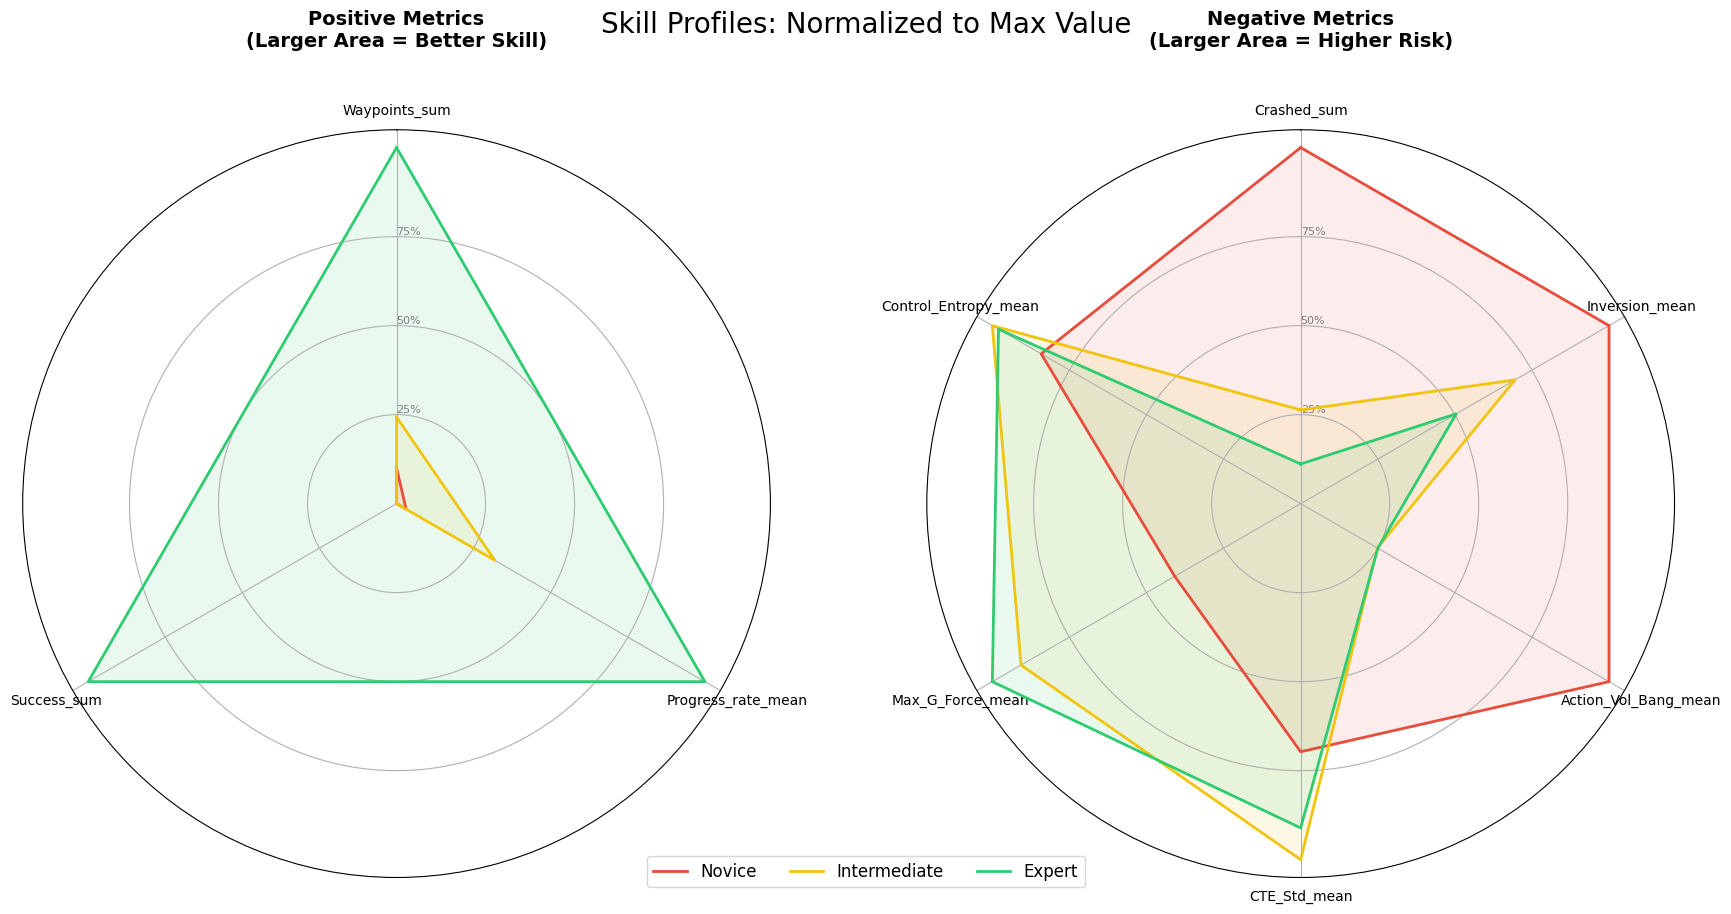


=== SKILL MIGRATION ANALYSIS ===

Condition: ALONE vs ARROW
-----------------------------------
  -> Improved:   7 ( 23.3%)
  -> Stayed:    17 ( 56.7%)
  -> Worsened:   6 ( 20.0%)
     [!] Warning: 6 pilots performed WORSE with Arrow.

Condition: ALONE vs GHOST-S1
-----------------------------------
  -> Improved:   1 (  3.3%)
  -> Stayed:    18 ( 60.0%)
  -> Worsened:  11 ( 36.7%)
     [!] Warning: 11 pilots performed WORSE with Ghost-S1.


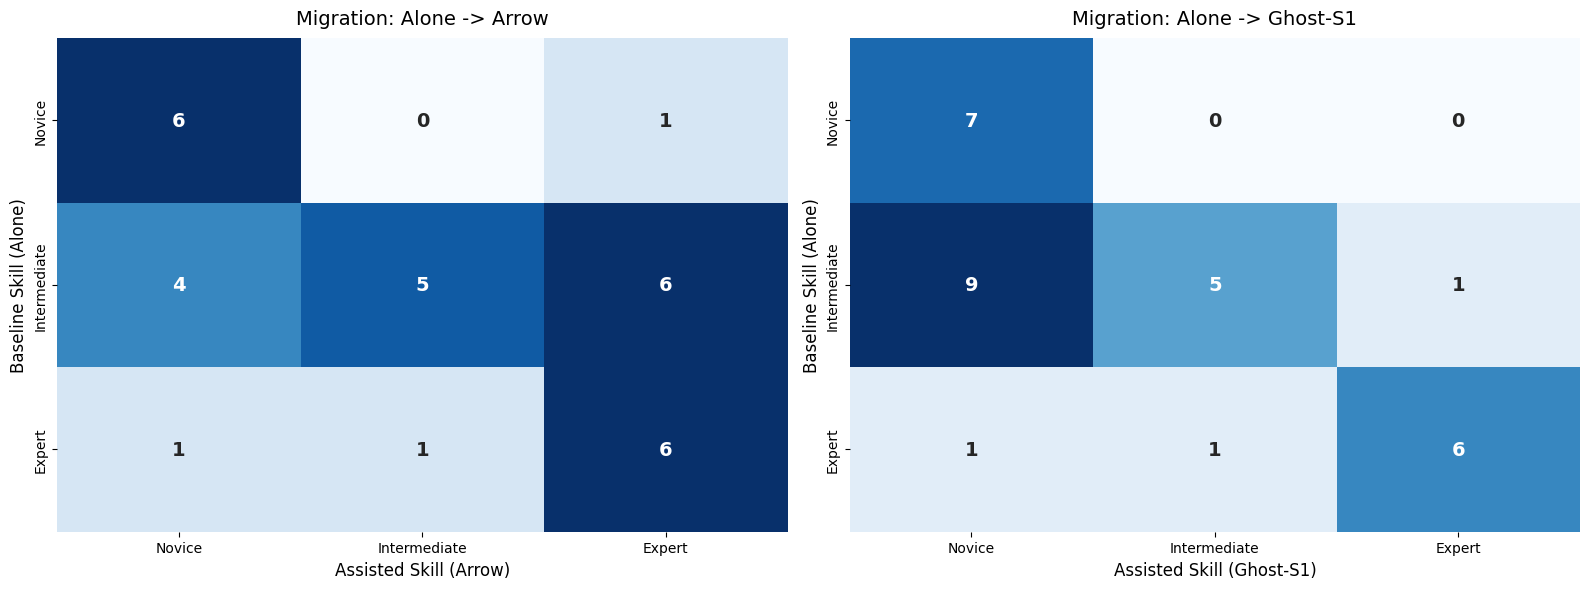


-> Saved Comparison Plot to 'skill_migration_comparison.png'


In [40]:
df_labeled, _, _ = perform_skill_analysis(df_subjects)
df_subjects_to_analyze = df_labeled[(df_labeled['Session'] == 1)]
plot_improved_split_radar(df_subjects_to_analyze)
analyze_skill_migration(df_subjects_to_analyze)

# Analysing performance and impacts due to assistance

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, spearmanr

# --- CONFIG ---
# Features to analyze (Must match your dataframe columns)
FEATURES = POSITIVE_METRICS + NEGATIVE_METRICS

def analyze_impact(df):
    """
    1. Statistical Significance: Did metrics change significantly? (Wilcoxon)
    2. Migration Drivers: Which metric changes correlated with Skill Improvement? (Spearman)
    """
    print("\n=== STATISTICAL IMPACT ANALYSIS ===")
    
    # 1. Pivot Data for Paired Analysis
    # We need: Subject | Metric_Alone | Metric_Arrow | Metric_Ghost
    pivot = df.pivot(index='Subject', columns='Condition', values=FEATURES + ['Skill_Cluster'])
    
    # Check if we have the necessary conditions
    if 'Alone' not in pivot.columns.get_level_values(1):
        print("Error: 'Alone' condition missing.")
        return

    results_table = []
    driver_correlations = []

    # Loop through Assists (Arrow, Ghost)
    for assist in ['Arrow', 'Ghost']:
        if assist not in pivot.columns.get_level_values(1): continue
        
        print(f"\n--- Analyzing Driver: {assist} ---")
        
        # Calculate Skill Migration (Change in Cluster Index: -1, 0, +1, +2)
        # Note: Skill_Cluster must be numeric (0=Novice, 1=Int, 2=Expert)
        # If it's string labels, map them first!
        delta_skill = pivot[( 'Skill_Cluster', assist)] - pivot[( 'Skill_Cluster', 'Alone')]
        
        for metric in FEATURES:
            # A. Statistical Significance (Did the metric change?)
            # Data for this metric
            data_alone = pivot[(metric, 'Alone')]
            data_assist = pivot[(metric, assist)]
            
            # Wilcoxon Signed-Rank Test (Non-parametric paired test)
            # We use 'pratt' method to handle zeros (cases where value didn't change)
            stat, p_val = wilcoxon(data_alone, data_assist, zero_method='pratt')
            
            # Median Difference (Effect Size proxy)
            median_delta = (data_assist - data_alone).median()
            
            # B. Migration Driver (Did this change cause the skill jump?)
            # Correlation between Delta_Metric and Delta_Skill
            delta_metric = data_assist - data_alone
            
            # Spearman Rank Correlation (Robust to outliers)
            corr, corr_p = spearmanr(delta_metric, delta_skill)
            
            # Store Results
            results_table.append({
                "Comparison": f"Alone vs {assist}",
                "Metric": metric,
                "Median_Delta": median_delta,
                "P_Value": p_val,
                "Significant": "YES" if p_val < 0.05 else "No"
            })
            
            driver_correlations.append({
                "Assist": assist,
                "Metric": metric,
                "Correlation": corr,
                "P_Value": corr_p
            })

    # --- OUTPUT 1: SIGNIFICANCE TABLE ---
    res_df = pd.DataFrame(results_table)
    print("\nSignificant Changes (p < 0.05):")
    print(res_df[res_df['Significant'] == 'YES'][['Comparison', 'Metric', 'P_Value', 'Median_Delta']])
    
    # Save full table
    res_df.to_csv("results/statistical_significance_results.csv", index=False)
    
    # --- OUTPUT 2: DRIVER PLOT ---
    driver_df = pd.DataFrame(driver_correlations)
    
    # Filter for meaningful correlations (optional, e.g., |r| > 0.1)
    # Plotting
    plt.figure(figsize=(12, 6))
    sns.barplot(data=driver_df, x='Metric', y='Correlation', hue='Assist', palette='muted')
    
    plt.axhline(0, color='black', linewidth=1)
    plt.title("What Drove the Skill Migration? (Correlation with Skill Jump)")
    plt.ylabel("Correlation with Skill Improvement\n(Positive = Metric Increase caused Jump)")
    plt.xlabel("Metric Changed")
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig("results/migration_drivers.png")
    plt.show()
    print("\n-> Saved Driver Analysis to 'migration_drivers.png'")
    
    return res_df, driver_df


In [100]:
# df_labeled.head()


=== STATISTICAL IMPACT ANALYSIS ===

--- Analyzing Driver: Arrow ---

--- Analyzing Driver: Ghost ---

Significant Changes (p < 0.05):
        Comparison                Metric       P_Value  Median_Delta
0   Alone vs Arrow         Waypoints_sum  1.049733e-03      2.000000
2   Alone vs Arrow    Progress_rate_mean  3.475989e-03      0.137500
6   Alone vs Arrow  Action_Vol_Bang_mean  7.494675e-03      5.263406
7   Alone vs Arrow          CTE_Std_mean  5.718321e-07     -5.724806
10  Alone vs Ghost         Waypoints_sum  4.756841e-02      0.500000
13  Alone vs Ghost     Progress_rate_std  4.332787e-02      0.015402
15  Alone vs Ghost        Inversion_mean  9.517744e-04      5.021678
16  Alone vs Ghost  Action_Vol_Bang_mean  3.800932e-04     15.882618
17  Alone vs Ghost          CTE_Std_mean  5.973503e-06     -6.474497
18  Alone vs Ghost      Max_G_Force_mean  3.453158e-05     -4.685263
19  Alone vs Ghost  Control_Entropy_mean  8.705463e-03     -0.267122


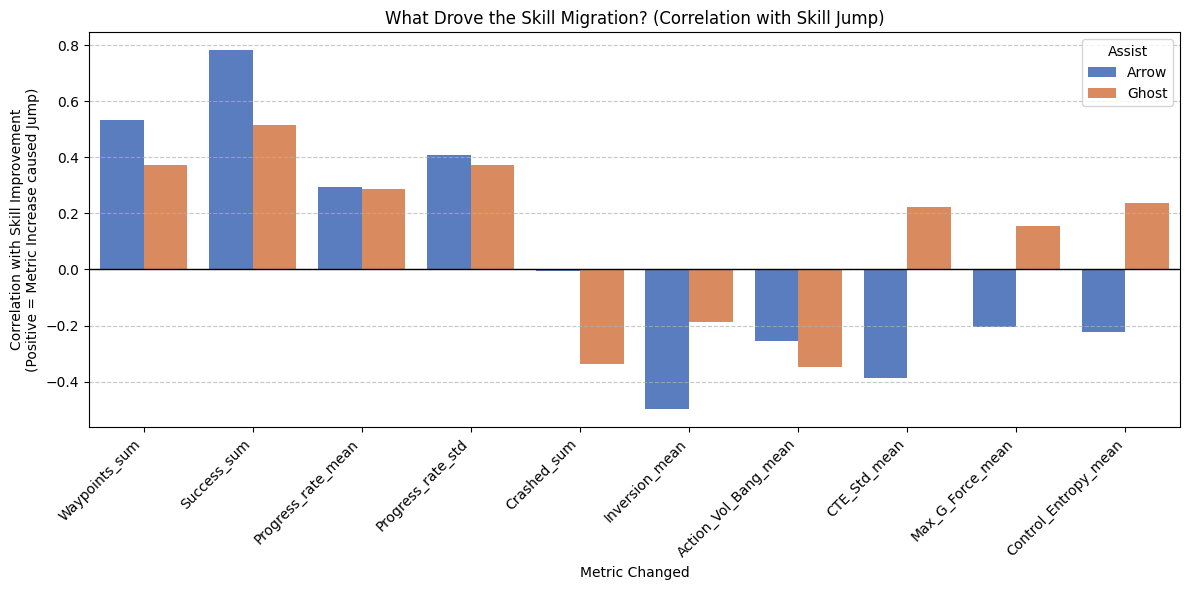


-> Saved Driver Analysis to 'migration_drivers.png'


In [101]:

# --- USAGE ---
# Assumes 'df' has 'Skill_Cluster' as NUMBERS (0,1,2)
# If 'Skill_Cluster' is labels ("Novice"), run this mapping first:
mapping = {"Novice": 0, "Intermediate": 1, "Expert": 2}
df_labeled['Skill_Cluster'] = df_labeled['Skill_Label'].map(mapping)
res_df, driver_df = analyze_impact(df_labeled)

In [86]:
res_df

,Comparison,Metric,Median_Delta,P_Value,Significant
0,Alone vs Arrow,Waypoints_sum,2.000000,1.049733e-03,YES
1,Alone vs Arrow,Success_sum,0.000000,6.273264e-02,No
2,Alone vs Arrow,Progress_rate_mean,0.137500,3.475989e-03,YES
3,Alone vs Arrow,Progress_rate_std,0.076335,7.331470e-02,No
4,Alone vs Arrow,Crashed_sum,-0.500000,1.525093e-01,No
5,Alone vs Arrow,Inversion_mean,3.110850,1.402830e-01,No
6,Alone vs Arrow,Action_Vol_Bang_mean,5.263406,7.494675e-03,YES
7,Alone vs Arrow,CTE_Std_mean,-5.724806,5.718321e-07,YES
8,Alone vs Arrow,Max_G_Force_mean,-2.541365,1.003974e-01,No
9,Alone vs Arrow,PIO_Count_Pitch_mean,-2.030556,9.032265e-01,No


In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from scipy.stats import mannwhitneyu
import os
import glob

# --- CONFIG ---
FPS = 60
FREQ_BANDS = {'Control': (0.1, 1.0), 'Correction': (1.0, 3.0), 'Jitter': (3.0, 10.0)}

def load_and_process_manifest(df, manifest_path):
    print("Loading Manifest...")
    try:
        manifest = pd.read_csv(manifest_path)
        
        if 'Subject_ID' in manifest.columns:
            man_subj_col = 'Subject_ID'
        elif 'Subject' in manifest.columns:
            man_subj_col = 'Subject'
        else:
            print(f"[!] Manifest missing 'Subject_ID'. Found: {manifest.columns}")
            return df

        order_map = {}
        for _, row in manifest.iterrows():
            subj_val = str(row[man_subj_col])
            t2 = str(row.get('Task_2', '')).lower().strip()
            t3 = str(row.get('Task_3', '')).lower().strip()
            
            if 'ghost' in t2:
                order_map[subj_val] = 'Ghost_First'
            elif 'ghost' in t3:
                order_map[subj_val] = 'Ghost_Second'
            else:
                order_map[subj_val] = 'Unknown'

        df['Order_Group'] = df['Subject'].astype(str).map(order_map)
        print(f"-> Groups Found: {df['Order_Group'].value_counts().to_dict()}")
        return df

    except Exception as e:
        print(f"[!] Error processing manifest: {e}")
        return df

def check_learning_effect(df, metric='Progress_rate_mean'):
    print(f"\n=== LEARNING EFFECT ANALYSIS (Metric: {metric}) ===")
    
    if 'Order_Group' not in df.columns:
        print("[!] Order_Group missing.")
        return

    ghost_df = df[df['Condition'] == 'Ghost']
    group_1st = ghost_df[ghost_df['Order_Group'] == 'Ghost_First'][metric]
    group_2nd = ghost_df[ghost_df['Order_Group'] == 'Ghost_Second'][metric]
    
    print(f"Total Ghost Flights: {len(ghost_df)}")
    print(f" -> Group A (Ghost 1st): {len(group_1st)}")
    print(f" -> Group B (Ghost 2nd): {len(group_2nd)}")

    if len(group_1st) < 2 or len(group_2nd) < 2:
        print("Not enough data.")
        return

    stat, p_val = mannwhitneyu(group_1st, group_2nd)
    
    print(f"Mean {metric} (Ghost 1st): {group_1st.mean():.2f}")
    print(f"Mean {metric} (Ghost 2nd): {group_2nd.mean():.2f}")
    print(f"P-Value: {p_val:.4f}")
    
    if p_val < 0.05:
        print("[!] SIGNIFICANT ORDER EFFECT.")
    else:
        print("[-] No significant order effect.")

def plot_control_psd(log_dir):
    print("\n=== GENERATING CONTROL PSD (PITCH) ===")
    
    psd_store = {'Alone': [], 'Arrow': [], 'Ghost': []}
    
    # Recursively find all .npz files
    files = glob.glob(os.path.join(log_dir, "**/*.npz"), recursive=True)
    if not files:
        print(f"[!] No .npz files found in {log_dir}.")
        return

    print(f"-> Found {len(files)} log files. Parsing...")
    common_freqs = np.linspace(0.1, 10, 100)
    
    processed_count = 0

    for fpath in files:
        # FIX: Check the FULL PATH for condition keywords, not just the filename
        # This handles cases like "task_arrow/data.npz"
        path_lower = fpath.lower()
        
        condition = None
        if 'arrow' in path_lower: condition = 'Arrow'
        elif 'ghost' in path_lower: condition = 'Ghost'
        elif 'manual' in path_lower or 'alone' in path_lower or 'task1' in path_lower: condition = 'Alone'
        
        if condition is None: continue

        try:
            data = np.load(fpath)
            
            # Robust key search for 'human_act'
            found_key = False
            for key in data.keys():
                if 'human_act' in key:
                    actions = data[key]
                    
                    # Ensure shape is (Time, 4)
                    # Index 1 is Pitch
                    if actions.ndim > 1 and actions.shape[1] >= 2:
                        pitch_input = actions[:, 1]
                        
                        # Calculate PSD
                        freqs, psd = welch(pitch_input, fs=FPS, nperseg=min(len(pitch_input), 256))
                        
                        # Interpolate to common bins for averaging
                        psd_interp = np.interp(common_freqs, freqs, psd)
                        psd_store[condition].append(psd_interp)
                        found_key = True
            
            if found_key:
                processed_count += 1
                
        except Exception as e:
            print(f"Error reading {fpath}: {e}")

    print(f"-> Successfully extracted PSD from {processed_count} files.")

    # --- PLOTTING ---
    plt.figure(figsize=(10, 6))
    colors = {'Alone': 'gray', 'Arrow': 'blue', 'Ghost': 'orange'}
    
    found_data = False
    for cond, psd_list in psd_store.items():
        if not psd_list: continue
        found_data = True
        
        arr = np.array(psd_list)
        mean_psd = np.mean(arr, axis=0)
        std_err = np.std(arr, axis=0) / np.sqrt(len(arr))
        
        plt.semilogy(common_freqs, mean_psd, label=cond, color=colors.get(cond, 'black'), linewidth=2)
        plt.fill_between(common_freqs, mean_psd - std_err, mean_psd + std_err, color=colors.get(cond, 'black'), alpha=0.1)

    if not found_data:
        print("[!] Still no valid PSD data. Please verify your folder structure contains 'Arrow'/'Ghost' strings.")
        return

    plt.axvspan(*FREQ_BANDS['Control'], color='green', alpha=0.1, label='Intentional')
    plt.axvspan(*FREQ_BANDS['Jitter'], color='red', alpha=0.1, label='Jitter')

    plt.title("Control Input Frequency Analysis (Pitch Stick)")
    plt.ylabel("Power Spectral Density (Log Scale)")
    plt.xlabel("Frequency (Hz)")
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.xlim(0, 5)
    
    plt.tight_layout()
    plt.savefig("results/control_psd_analysis.png")
    plt.show()
    print("-> Saved PSD Plot to 'control_psd_analysis.png'")



In [103]:
# df_labeled.columns

Loading Manifest...
-> Groups Found: {'Ghost_First': 78, 'Ghost_Second': 12}

=== LEARNING EFFECT ANALYSIS (Metric: Progress_rate_mean) ===
Total Ghost Flights: 30
 -> Group A (Ghost 1st): 26
 -> Group B (Ghost 2nd): 4
Mean Progress_rate_mean (Ghost 1st): 0.30
Mean Progress_rate_mean (Ghost 2nd): 0.21
P-Value: 0.7132
[-] No significant order effect.

=== GENERATING CONTROL PSD (PITCH) ===
-> Found 189 log files. Parsing...
-> Successfully extracted PSD from 159 files.


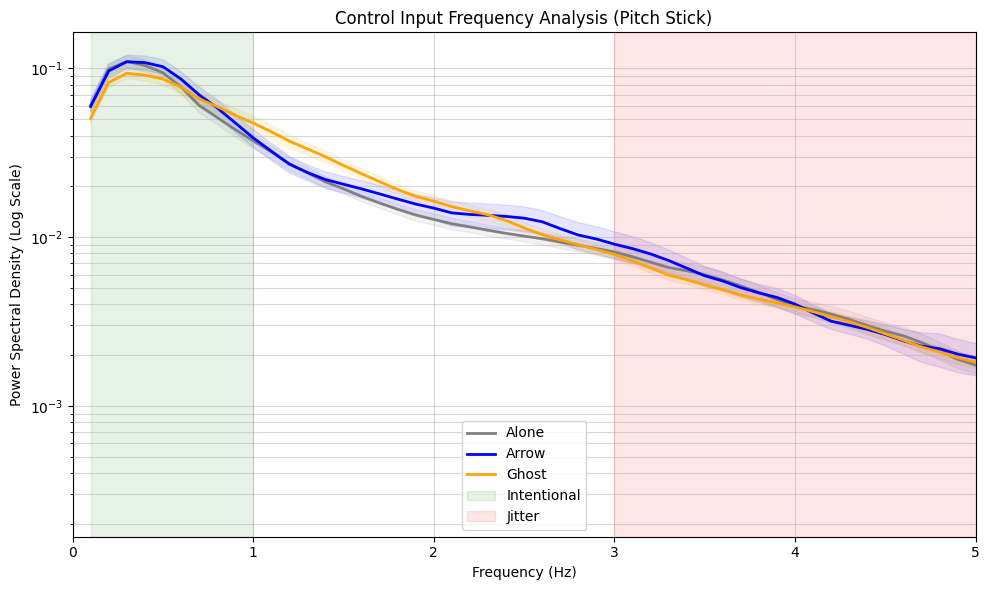

-> Saved PSD Plot to 'control_psd_analysis.png'


In [104]:

# --- RUN BLOCK ---

# 1. Load Metrics
# summary_df = pd.read_csv("metrics_per_flight.csv")

# 2. Process Manifest
df_labeled = load_and_process_manifest(df_labeled, "flight_data/experiment_manifest.csv")

# # 3. Check Learning
check_learning_effect(df_labeled, metric='Progress_rate_mean')

# # 4. Generate PSD
plot_control_psd("flight_data")

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math


In [119]:

def plot_differences_clean_stats(df, stats_df, metrics, baseline_cond, test_conds, metric_labels=None):
    """
    Plots difference scores with a uniform color palette. 
    Uses a dictionary to map raw metric names to clean publication labels.
    Statistical significance is appended directly to the X-axis labels.
    """
    print(f"Generating Plots against Baseline: [{baseline_cond}]")
    
    # 1. Calculate Deltas (Test - Baseline)
    df_base = df[df['Condition'] == baseline_cond].set_index('Subject')[metrics]
    diff_dataframes = []
    
    for tc in test_conds:
        df_test = df[df['Condition'] == tc].set_index('Subject')[metrics]
        df_diff = df_test - df_base
        df_diff['Test_Condition'] = tc
        diff_dataframes.append(df_diff.reset_index())
        
    df_all_diffs = pd.concat(diff_dataframes, ignore_index=True)

    # 2. Setup Plotting Grid
    cols = 3 
    rows = math.ceil(len(metrics) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten() if len(metrics) > 1 else [axes]
    
    # 3. Draw Plots
    for i, metric in enumerate(metrics):
        ax = axes[i]
        plot_data = df_all_diffs.dropna(subset=[metric])
        
        if plot_data.empty: continue
        
        # Draw Box and Strip plots with uniform colors
        sns.boxplot(data=plot_data, x='Test_Condition', y=metric, ax=ax, 
                    palette='Set2', width=0.5, showfliers=False)
        sns.stripplot(data=plot_data, x='Test_Condition', y=metric, ax=ax, 
                      color="black", alpha=0.7, size=5, jitter=True)
        
        # The Critical "Zero Line"
        ax.axhline(0, color='red', linestyle='--', linewidth=2, zorder=0)

        # --- UPDATE X-AXIS LABELS WITH STATS ---
        new_labels = []
        for tc in test_conds:
            comp_string = f"{baseline_cond} vs {tc}"
            
            # Find the matching row in stats_df
            match = stats_df[(stats_df['Metric'] == metric) & 
                             (stats_df['Comparison'] == comp_string)]
            
            annot = "(ns)" # Default to not significant
            
            if not match.empty:
                raw_val = match['Significant'].values[0]
                
                # Robust boolean check
                if isinstance(raw_val, bool):
                    is_sig = raw_val
                else:
                    is_sig = str(raw_val).strip().lower() in ['true', '1', 'yes', 't']
                
                if is_sig:
                    p_val = match['P_Value'].values[0]
                    if p_val < 0.001: annot = "***"
                    elif p_val < 0.01: annot = "**"
                    else: annot = "*"
            
            # Combine condition name and annotation
            new_labels.append(f"{tc}\n{annot}")
            
        # Apply the new X-axis labels to the current subplot
        ax.set_xticks(range(len(test_conds)))
        ax.set_xticklabels(new_labels, fontsize=10)
        
        # --- NEW: APPLY CLEAN METRIC LABELS ---
        # Look up the clean name. If not found in the dictionary, fall back to the raw metric name.
        display_name = metric
        if metric_labels and metric in metric_labels:
            display_name = metric_labels[metric]
        
        # Formatting using the clean display name
        ax.set_title(f"$\Delta$ {display_name}", fontsize=12, fontweight='bold')
        ax.set_ylabel("Difference Score")
        ax.set_xlabel("") 
        
    # Clean up empty subplots
    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

Generating Plots against Baseline: [Alone]


/var/folders/m7/3gmhx7wd5nl_mz69sfmj1gjw0000gn/T/ipykernel_59978/3066052039.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='Test_Condition', y=metric, ax=ax,
/var/folders/m7/3gmhx7wd5nl_mz69sfmj1gjw0000gn/T/ipykernel_59978/3066052039.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='Test_Condition', y=metric, ax=ax,
/var/folders/m7/3gmhx7wd5nl_mz69sfmj1gjw0000gn/T/ipykernel_59978/3066052039.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='Test_Condition', y=metric, ax=ax,
/

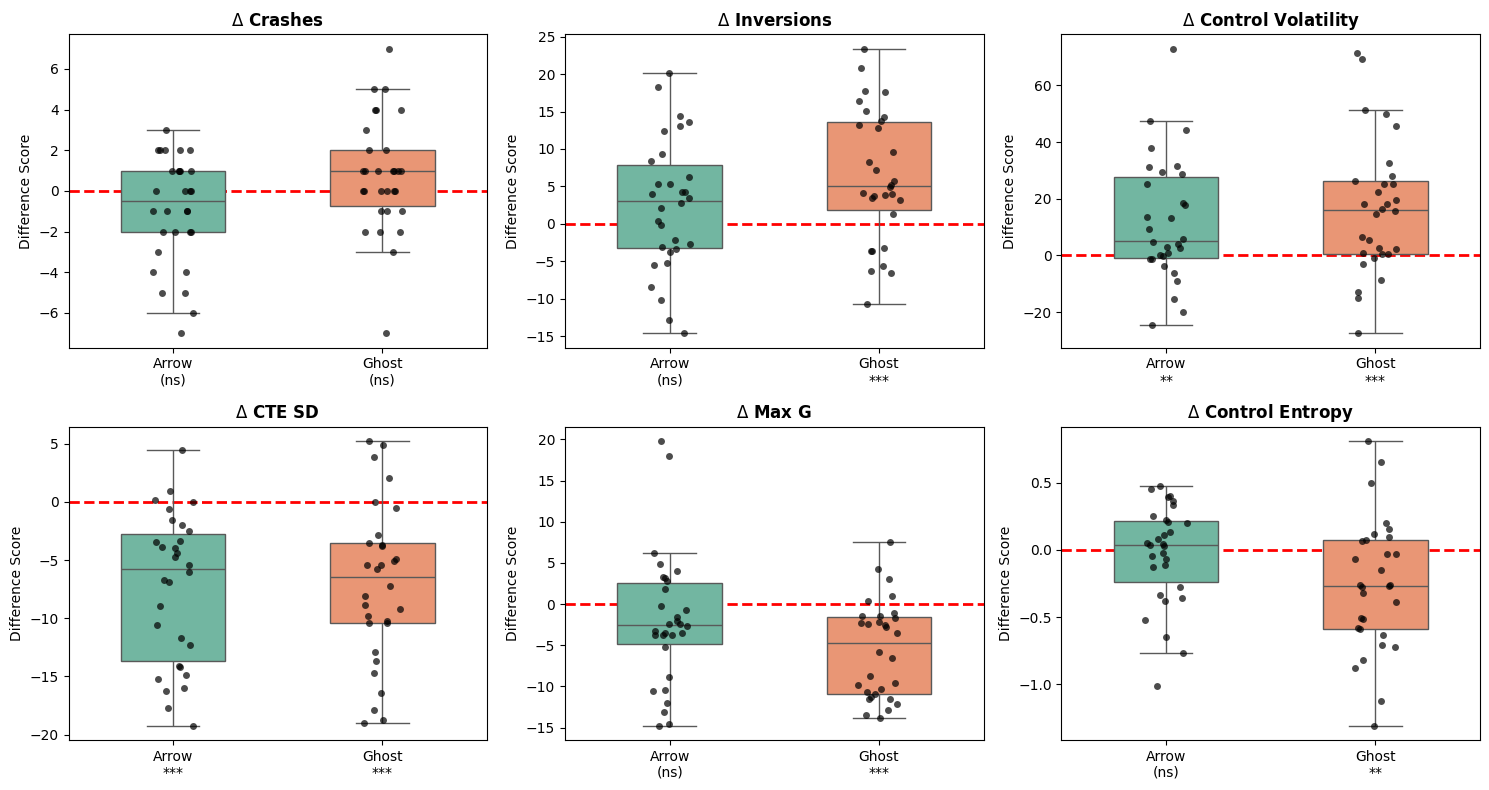

In [120]:
plot_differences_clean_stats(df_subjects, res_df, NEGATIVE_METRICS, "Alone", ["Arrow", "Ghost"], metric_labels=metric_labels_pub)


In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_spatial_precision_density(df):
    print("Generating Spatial Precision Distribution...")
    
    # We use CTE_Avg (Average Cross Track Error) as the proxy for spatial precision
    # A density plot visualizes the probability of a pilot having a certain error.
    
    plt.figure(figsize=(10, 6))
    
    # KDE Plot (Kernel Density Estimate) - Smooths the histogram
    # fill=True creates the "Mountain" effect
    sns.kdeplot(
        data=df, 
        x="CTE_Avg", 
        hue="Condition", 
        fill=True, 
        palette={"Alone": "grey", "Arrow": "blue", "Ghost": "orange"},
        alpha=0.3,
        linewidth=2
    )
    
    plt.title("Spatial Analysis: Precision Distribution (CTE)", fontsize=14)
    plt.xlabel("Average Deviation from Path (meters)\n(0 = Perfect Flight)", fontsize=12)
    plt.ylabel("Density (Frequency of Pilots)", fontsize=12)
    plt.xlim(0, 50) # Limit x-axis to zoom in on the relevant area (adjust if needed)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig("spatial_precision_density.png")
    plt.show()
    print("-> Saved plot to 'spatial_precision_density.png'")



Generating Spatial Precision Distribution...


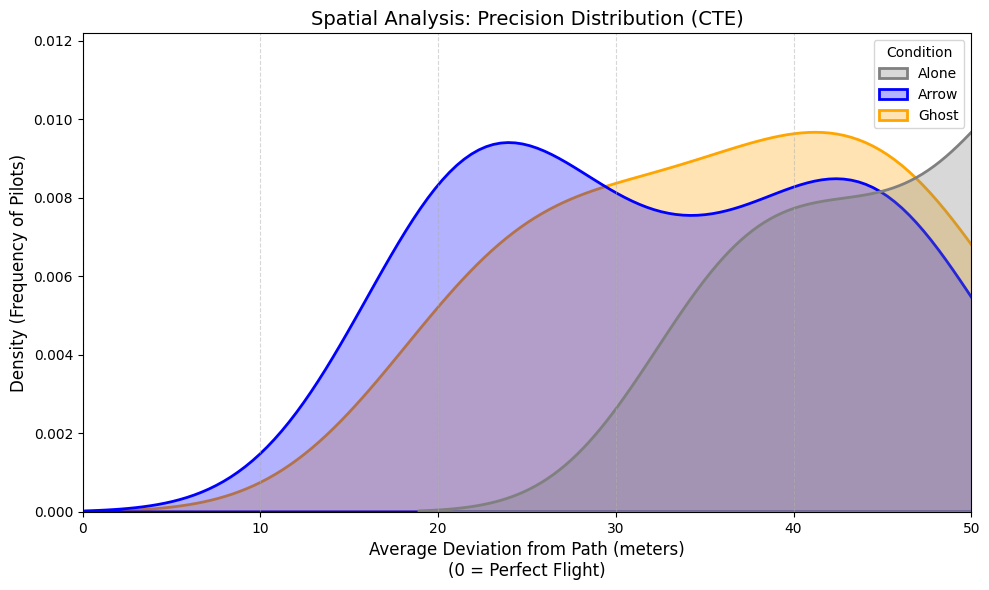

-> Saved plot to 'spatial_precision_density.png'


In [18]:

# df = pd.read_csv("metrics_per_flight.csv")

# Ensure condition names match your CSV (e.g., 'Alone' vs 'Manual')
# If your CSV uses 'Alone', map it or update the palette above.
# if 'Alone' in df['Condition'].values:
#     df['Condition'] = df['Condition'].replace('Alone', 'Manual')
    
plot_spatial_precision_density(df_labeled)

# survey analysis

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import friedmanchisquare, wilcoxon, chisquare

# --- CONFIGURATION ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
PALETTE = {"Alone": "#95a5a6", "Ghost": "#e67e22", "Arrow": "#2980b9"}

# --- EXACT DICTIONARIES FROM USER ---
TASK_1_QUESTIONS = {
    "How would you rate your performance in the task?": {"Extremely Poor": 1, "Poor": 2, "Below Average": 3, "Average": 4, "Above Average": 5, "Good": 6, "Excellent": 7}, 
    "How mentally demanding was the task?": {"Very Low": 1, "Low": 2, "Somewhat Low": 3, "Neither Low or High": 4, "Somewhat High": 5, "High": 6, "Very High": 7},
    "How physically demanding was the task?": {"Very Low": 1, "Low": 2, "Somewhat Low": 3, "Neither Low or High": 4, "Somewhat High": 5, "High": 6, "Very High": 7},
    "How hurried or rushed was the pace of the task?": {"Very Low": 1, "Low": 2, "Somewhat Low": 3, "Neither Low or High": 4, "Somewhat High": 5, "High": 6, "Very High": 7},
    "How hard did you have to work to accomplish your level of performance?": {"Very Low": 1, "Low": 2, "Somewhat Low": 3, "Neither Low or High": 4, "Somewhat High": 5, "High": 6, "Very High": 7},
    "How insecure, discouraged, irritated, stressed, or annoyed were you?": {"Very Low": 1, "Low": 2, "Somewhat Low": 3, "Neither Low or High": 4, "Somewhat High": 5, "High": 6, "Very High": 7}
}

TASK_2_QUESTIONS = {
    "How would you rate your performance in the task?.2": {"Extremely Poor": 1, "Poor": 2, "Below Average": 3, "Average": 4, "Above Average": 5, "Good": 6, "Excellent": 7}, 
    "How mentally demanding was the task?.2": {"Very Low": 1, "Low": 2, "Somewhat Low": 3, "Neither Low or High": 4, "Somewhat High": 5, "High": 6, "Very High": 7},
    "How physically demanding was the task?.2": {"Very Low": 1, "Low": 2, "Somewhat Low": 3, "Neither Low or High": 4, "Somewhat High": 5, "High": 6, "Very High": 7},
    "How hurried or rushed was the pace of the task?.2": {"Very Low": 1, "Low": 2, "Somewhat Low": 3, "Neither Low or High": 4, "Somewhat High": 5, "High": 6, "Very High": 7},
    "How hard did you have to work to accomplish your level of performance?.2": {"Very Low": 1, "Low": 2, "Somewhat Low": 3, "Neither Low or High": 4, "Somewhat High": 5, "High": 6, "Very High": 7},
    "How insecure, discouraged, irritated, stressed, or annoyed were you?.2": {"Very Low": 1, "Low": 2, "Somewhat Low": 3, "Neither Low or High": 4, "Somewhat High": 5, "High": 6, "Very High": 7},
    "How did the AI's suggestions change your performance?": {"Decreased performance significantly": 1, "Decreased performance": 2, "Slightly decreased performance": 3, "No significant impact on performance": 4, "Slightly improved performance": 5, "Improved performance": 6, "Significantly improved performance": 7},
    "Overall, how much do you trust the AI?": {"No trust at all": 1, "Very low trust": 2, "Low trust": 3, "Moderate trust": 4, "High trust": 5, "Very high trust": 6, "Complete trust": 7}
}

TASK_3_QUESTIONS = {
    "How would you rate your performance in the task?.3": {"Extremely Poor": 1, "Poor": 2, "Below Average": 3, "Average": 4, "Above Average": 5, "Good": 6, "Excellent": 7}, 
    "How mentally demanding was the task?.3": {"Very Low": 1, "Low": 2, "Somewhat Low": 3, "Neither Low or High": 4, "Somewhat High": 5, "High": 6, "Very High": 7},
    "How physically demanding was the task?.3": {"Very Low": 1, "Low": 2, "Somewhat Low": 3, "Neither Low or High": 4, "Somewhat High": 5, "High": 6, "Very High": 7},
    "How hurried or rushed was the pace of the task?.3": {"Very Low": 1, "Low": 2, "Somewhat Low": 3, "Neither Low or High": 4, "Somewhat High": 5, "High": 6, "Very High": 7},
    "How hard did you have to work to accomplish your level of performance?.3": {"Very Low": 1, "Low": 2, "Somewhat Low": 3, "Neither Low or High": 4, "Somewhat High": 5, "High": 6, "Very High": 7},
    "How insecure, discouraged, irritated, stressed, or annoyed were you?.3 ": {"Very Low": 1, "Low": 2, "Somewhat Low": 3, "Neither Low or High": 4, "Somewhat High": 5, "High": 6, "Very High": 7},
    "How did the AI's suggestions change your performance?.2": {"Decreased performance significantly": 1, "Decreased performance": 2, "Slightly decreased performance": 3, "No significant impact on performance": 4, "Slightly improved performance": 5, "Improved performance": 6, "Significantly improved performance": 7},
    "Overall, how much do you trust the AI?.2": {"No trust at all": 1, "Very low trust": 2, "Low trust": 3, "Moderate trust": 4, "High trust": 5, "Very high trust": 6, "Complete trust": 7}
}

FINAL_QUESTIONS = {
    "Comparing the assistance provided in task 2 vs task 3, which mode would you prefer?": {
        "Strongly prefer task 2": 3,
        "Prefer task 2": 2,
        "Slightly prefer task 2": 1,
        "No preference": 0,
        "Slightly prefer task 3": 1,
        "Prefer task 3": 2,
        "Strongly prefer task 3": 3
    }
}

import pandas as pd
import numpy as np

# --- 1. DEFINE SURVEY COLUMN GROUPS ---
# These map the raw CSV column names to their logical group

# Task 1 (Alone) - Baseline columns (No suffixes)
t1_cols = {
    'Mental': 'How mentally demanding was the task?',
    'Physical': 'How physically demanding was the task?',
    'Temporal': 'How hurried or rushed was the pace of the task?',
    'Performance': 'How would you rate your performance in the task?',
    'Effort': 'How hard did you have to work to accomplish your level of performance?',
    'Frustration': 'How insecure, discouraged, irritated, stressed, or annoyed were you?'
}

# Task 2 - First AI interaction (Suffix .1 for TLX, No suffix for AI specific)
t2_cols = {
    'Mental': 'How mentally demanding was the task?.1',
    'Physical': 'How physically demanding was the task?.1',
    'Temporal': 'How hurried or rushed was the pace of the task?.1',
    'Performance': 'How would you rate your performance in the task?.1',
    'Effort': 'How hard did you have to work to accomplish your level of performance?.1',
    'Frustration': 'How insecure, discouraged, irritated, stressed, or annoyed were you?.1',
    'AI_Impact': "How did the AI's suggestions change your performance?",
    'AI_Trust': 'Overall, how much do you trust the AI?'
}

# Task 3 - Second AI interaction (Suffix .2 for TLX, Suffix .1 for AI specific)
t3_cols = {
    'Mental': 'How mentally demanding was the task?.2',
    'Physical': 'How physically demanding was the task?.2',
    'Temporal': 'How hurried or rushed was the pace of the task?.2',
    'Performance': 'How would you rate your performance in the task?.2',
    'Effort': 'How hard did you have to work to accomplish your level of performance?.2',
    'Frustration': 'How insecure, discouraged, irritated, stressed, or annoyed were you?.2',
    'AI_Impact': "How did the AI's suggestions change your performance?.1",
    'AI_Trust': 'Overall, how much do you trust the AI?.1'
}

# Preference Parsing Logic
PREF_STRENGTH_MAP = {
    "strongly prefer task 2": (3, "Task 2"),
    "prefer task 2": (2, "Task 2"),
    "slightly prefer task 2": (1, "Task 2"),
    "no preference": (0, "None"),
    "slightly prefer task 3": (1, "Task 3"),
    "prefer task 3": (2, "Task 3"),
    "strongly prefer task 3": (3, "Task 3")
}



In [20]:
def merge_survey_into_metrics(metrics_df, survey_df):
    print(">>> Starting Merge (Metrics + Survey + Preference)...")
    
    # 1. Subject ID Cleanup
    # Check for existing 'Subject' column in Survey
    if 'Subject' not in survey_df.columns:
        possible = [c for c in survey_df.columns if 'Subject' in c]
        if possible:
            survey_df = survey_df.rename(columns={possible[0]: 'Subject'})
        else:
            raise KeyError("Survey missing 'Subject' column.")

    # Ensure integer matching
    metrics_df['Subject'] = metrics_df['Subject'].astype(int)
    survey_df['Subject'] = pd.to_numeric(survey_df['Subject'], errors='coerce')
    survey_df = survey_df.dropna(subset=['Subject'])
    survey_df['Subject'] = survey_df['Subject'].astype(int)

    merged_data = []

    # 2. Iterate Logic
    for index, row in metrics_df.iterrows():
        subj_id = row['Subject']
        condition = row['Condition']     # Alone, Ghost, Arrow
        order_group = row['Order_Group'] # Ghost_First, Ghost_Second
        
        # Fetch Survey Data
        subj_survey = survey_df[survey_df['Subject'] == subj_id]
        if subj_survey.empty:
            continue
        
        subj_data = subj_survey.iloc[0].to_dict()
        new_cols = {}

        # --- A. MERGE STANDARD QUESTIONS ---
        if condition == 'Alone':
            for std, csv in t1_cols.items():
                new_cols[f"Survey_{std}"] = subj_data.get(csv)
            # Fill N/A for AI questions
            new_cols["Survey_AI_Trust"] = "N/A" 
            new_cols["Survey_AI_Impact"] = "N/A" 
        else:
            # Logic: Map Condition -> Task Number -> Columns
            target_cols = None
            if condition == 'Ghost':
                target_cols = t2_cols if order_group == 'Ghost_First' else t3_cols
            elif condition == 'Arrow':
                target_cols = t3_cols if order_group == 'Ghost_First' else t2_cols
            
            if target_cols:
                for std, csv in target_cols.items():
                    new_cols[f"Survey_{std}"] = subj_data.get(csv)

        # --- B. MERGE PREFERENCE (0-3 Logic) ---
        pref_raw = str(subj_data.get('Comparing the assistance provided in task 2 vs task 3, which mode would you prefer?', '')).lower().strip()
        reason_raw = str(subj_data.get('Why did you think the guidance method you chose was better than the other? ', '')).strip()
        
        # 1. Parse Strength & Task
        strength, pref_task = PREF_STRENGTH_MAP.get(pref_raw, (0, "None"))
        
        # 2. Decode Preferred Condition
        preferred_cond_name = "None"
        if pref_task == "Task 2":
            preferred_cond_name = "Ghost" if order_group == 'Ghost_First' else "Arrow"
        elif pref_task == "Task 3":
            preferred_cond_name = "Arrow" if order_group == 'Ghost_First' else "Ghost"
            
        # 3. Assign Score (Target Row Only)
        # If this row matches the preferred condition, give it the score. Otherwise 0.
        if condition == preferred_cond_name:
            new_cols['Preference_Strength'] = strength
        else:
            new_cols['Preference_Strength'] = 0
            
        # 4. Include Reason (Repeated for context, or you can blank it out similarly)
        # Usually text is useful everywhere, but I'll add it to all rows for this subject.
        new_cols['Preference_Reason'] = reason_raw

        # Combine
        row_dict = row.to_dict()
        row_dict.update(new_cols)
        merged_data.append(row_dict)

    final_df = pd.DataFrame(merged_data)
    print(f"Merge Complete. Shape: {final_df.shape}")
    return final_df

In [21]:
# --- LOAD & MERGE ---
try:
    survey = pd.read_csv('session1-survey.csv')
    
except FileNotFoundError:
    print("Error: Files not found.")

# Clean Headers
# survey.columns = survey.columns.str.strip()
# survey["Subject"] = survey["Subject ID (ask from experimenter) "]


In [22]:
# Assuming you have loaded your dataframes as 'metrics_df' and 'survey_df'

# 1. Run the merge
full_dataset = merge_survey_into_metrics(df_labeled, survey)

# 2. Verify the Result
# We should see Objective Metrics (Waypoints) side-by-side with Subjective Metrics (Survey_Mental)
print("\nSample of Merged Data (Ghost Condition):")
print(full_dataset[full_dataset['Condition'] == 'Ghost'][['Subject', 'Condition', 'Waypoints', 'Survey_Mental', 'Survey_AI_Trust']].head())

print("\nSample of Merged Data (Alone Condition):")
print(full_dataset[full_dataset['Condition'] == 'Alone'][['Subject', 'Condition', 'Waypoints', 'Survey_Mental', 'Survey_AI_Trust']].head())

>>> Starting Merge (Metrics + Survey + Preference)...
Merge Complete. Shape: (90, 40)

Sample of Merged Data (Ghost Condition):
    Subject Condition  Waypoints        Survey_Mental Survey_AI_Trust
2         1     Ghost          4  Neither Low or High       Low trust
5         2     Ghost         11        Somewhat High  Moderate trust
8         3     Ghost          1                 High  Very low trust
11        4     Ghost          1  Neither Low or High  Moderate trust
14        5     Ghost          3  Neither Low or High  Moderate trust

Sample of Merged Data (Alone Condition):
    Subject Condition  Waypoints        Survey_Mental Survey_AI_Trust
0         1     Alone          2         Somewhat Low             N/A
3         2     Alone         10        Somewhat High             N/A
6         3     Alone          1            Very High             N/A
9         4     Alone          0         Somewhat Low             N/A
12        5     Alone          6  Neither Low or High       

In [23]:
full_dataset.head()

,Subject,Session,Condition,Waypoints,Crashed,Success,Failures,Time_Total,Time_Success,Near_Misses,...,Survey_Mental,Survey_Physical,Survey_Temporal,Survey_Performance,Survey_Effort,Survey_Frustration,Survey_AI_Trust,Survey_AI_Impact,Preference_Strength,Preference_Reason
0,1,1,Alone,2,1,0,2,150.021000,NaN,4,...,Somewhat Low,Somewhat High,High,Extremely Poor,Somewhat High,High,N/A,N/A,0,Because it told me where to go and how far I w...
1,1,1,Arrow,7,0,1,1,150.026500,152.3380,5,...,Neither Low or High,Somewhat High,High,Good,Somewhat High,Somewhat Low,High trust,Improved performance,3,Because it told me where to go and how far I w...
2,1,1,Ghost,4,2,0,3,100.003667,NaN,3,...,Neither Low or High,Somewhat High,High,Average,High,Somewhat High,Low trust,Slightly improved performance,0,Because it told me where to go and how far I w...
3,2,1,Alone,10,0,2,1,100.024333,135.3135,5,...,Somewhat High,Neither Low or High,Somewhat High,Average,High,Somewhat Low,N/A,N/A,0,I liked the arrow because it gave me awareness...
4,2,1,Arrow,9,1,1,3,75.014000,104.6120,3,...,Neither Low or High,Neither Low or High,Somewhat Low,Average,Somewhat Low,Somewhat Low,High trust,Slightly improved performance,1,I liked the arrow because it gave me awareness...


In [24]:
# --- 2. Q1: PERCEPTION VS REALITY ---

def clean_survey_data(df):
    print(">>> Cleaning Survey Data (Converting Text to Numbers)...")
    df = df.copy()
    
    # 1. Define Mappings
    tlx_map = {"Very Low": 1, "Low": 2, "Somewhat Low": 3, "Neither Low or High": 4, "Somewhat High": 5, "High": 6, "Very High": 7}
    
    perf_map = {"Extremely Poor": 1, "Poor": 2, "Below Average": 3, "Average": 4, "Above Average": 5, "Good": 6, "Excellent": 7}


    # 2. Helper to apply map safely
    def convert(val, mapping):
        if pd.isna(val): return np.nan
        if isinstance(val, (int, float)): return val
        s_val = str(val).strip()
        return mapping.get(s_val, np.nan)

    # 3. Apply to columns
    # TLX Columns
    for col in ['Survey_Mental', 'Survey_Physical', 'Survey_Temporal', 'Survey_Frustration', 'Survey_Effort']:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: convert(x, tlx_map))
            
    # Performance Column
    if 'Survey_Performance' in df.columns:
        df['Survey_Performance'] = df['Survey_Performance'].apply(lambda x: convert(x, perf_map))
        
    print("-> Data Cleaned. Text ratings are now numbers 1-7.")
    return df

def analyze_perception(df):
    print("\n>>> Q1: Perception vs. Reality (Delta Analysis)...")
    
    
    # 2. Aggregation (Subject Level)
    # Pivot to get Alone vs Assist columns for each subject
    # We aggregate by Subject/Condition to handle multiple flights per subject
    # Note: Survey_Performance is constant per subject, Waypoints is averaged
    df_agg = df.groupby(['Subject', 'Condition'])[['Waypoints', 'Survey_Performance']].mean().reset_index()
    
    # Pivot for Delta Calculation
    wide_df = df_agg.pivot(index='Subject', columns='Condition', values=['Waypoints', 'Survey_Performance'])
    
    # 3. Calculate Deltas (Assist - Alone)
    for assist in ['Ghost', 'Arrow']:
        # Check if we have data for this condition
        if assist not in wide_df['Waypoints'].columns or 'Alone' not in wide_df['Waypoints'].columns:
            print(f"   [!] Skipping {assist}: Missing data.")
            continue
            
        # Objective Delta (Actual Score)
        wide_df[f'Delta_Obj_{assist}'] = wide_df[('Waypoints', assist)] - wide_df[('Waypoints', 'Alone')]
        # Subjective Delta (Perceived Rating)
        wide_df[f'Delta_Subj_{assist}'] = wide_df[('Survey_Performance', assist)] - wide_df[('Survey_Performance', 'Alone')]
    
    # 4. Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for i, assist in enumerate(['Ghost', 'Arrow']):
        col_x = f'Delta_Obj_{assist}'
        col_y = f'Delta_Subj_{assist}'
        
        if col_x not in wide_df.columns: 
            axes[i].text(0.5, 0.5, "No Data", ha='center')
            continue

        x = wide_df[col_x]
        y = wide_df[col_y]
        
        # Drop NaNs for valid stats
        valid = pd.DataFrame({'x': x, 'y': y}).dropna()
        
        label = "Insufficient Data"
        if len(valid) > 2:
            corr, p = spearmanr(valid['x'], valid['y'])
            label = f"Spearman r={corr:.2f} (p={p:.3f})"

        sns.scatterplot(x=x, y=y, ax=axes[i], color=PALETTE.get(assist, 'blue'), s=100)
        
        # Only plot regression line if we have enough points
        if len(valid) > 1:
            sns.regplot(x=x, y=y, ax=axes[i], color=PALETTE.get(assist, 'blue'), scatter=False, ci=None)
        
        axes[i].set_title(f"{assist}: Perception vs Reality\n{label}", fontweight='bold')
        axes[i].set_xlabel("Actual Improvement (Delta Waypoints)")
        axes[i].set_ylabel("Perceived Improvement (Delta Rating)")
        axes[i].axhline(0, color='grey', linestyle='--', alpha=0.5)
        axes[i].axvline(0, color='grey', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig("q1_perception_vs_reality.png")
    print("-> Saved 'q1_perception_vs_reality.png'")


# --- 3. Q2: COST OF CONTROL ---
def analyze_cost(df):
    print("\n>>> Q2: The Cost of Control (Behavior vs Feeling)...")
    
    # Target columns
    subj_cols = ['Survey_Physical', 'Survey_Frustration']
    obj_cols = ['Energy_Variance', 'PIO_Count_Pitch']
    
    # Check if columns exist
    missing = [c for c in subj_cols + obj_cols if c not in df.columns]
    if missing:
        print(f"[!] Missing columns for Cost Analysis: {missing}")
        return

    # Filter and Drop NaNs
    corr_df = df[subj_cols + obj_cols].dropna()
    
    # FORCE NUMERIC (Safety Check)
    # If clean_survey_data wasn't run, this tries to coerce or fails gracefully
    for col in subj_cols:
        corr_df[col] = pd.to_numeric(corr_df[col], errors='coerce')
    
    # Drop rows that failed conversion
    corr_df = corr_df.dropna()
    
    if corr_df.empty:
        print("[!] No valid data. Did you run clean_survey_data(df)?")
        return

    # Calculate Correlation
    corr_matrix = corr_df.corr(method='spearman')
    
    # Plot Heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
    plt.title("Correlation: Feelings (Survey) vs Physics (Flight)", fontweight='bold')
    plt.tight_layout()
    plt.savefig("q2_cost_correlation.png")
    print("-> Saved 'q2_cost_correlation.png'")
    
    # Print Key Results
    print("\nKey Correlations (Spearman):")
    p_phys = corr_matrix.loc['Survey_Physical', 'Energy_Variance']
    p_frust = corr_matrix.loc['Survey_Frustration', 'PIO_Count_Pitch']
    print(f"   Physical Demand vs Energy Variance: {p_phys:.2f}")
    print(f"   Frustration vs PIO (Pitch):         {p_frust:.2f}")



# --- 4. Q3: PREFERENCE RATIONALITY ---
def analyze_preference(df):
    print("\n>>> Q3: Preference Rationality (Fixed Skill Grouping)...")
    
    # 1. Fix Skill Labels (Use 'Alone' as the Baseline Truth)
    # Extract the skill label from the Alone condition for each subject
    baseline_skills = df[df['Condition'] == 'Alone'][['Subject', 'Skill_Label']].drop_duplicates()
    
    # Handle duplicates if a subject has multiple Alone flights (take the first or most frequent)
    baseline_skills = baseline_skills.groupby('Subject').first().reset_index()
    
    baseline_skills = baseline_skills.rename(columns={'Skill_Label': 'Baseline_Skill'})
    
    # Merge this static label back into the main dataframe
    # We drop the old dynamic 'Skill_Label' to avoid confusion if needed, 
    # but for now we just add 'Baseline_Skill'
    df_fixed = df.merge(baseline_skills, on='Subject', how='left')
    
    # Fill any missing skills (e.g. if they didn't fly Alone) with 'Unknown'
    df_fixed['Baseline_Skill'] = df_fixed['Baseline_Skill'].fillna('Unknown')
    
    print(f"   -> Skill Labels normalized. Using Baseline (Alone) skill for all conditions.")

    # 2. Pivot Performance (Now grouping by the Static Baseline_Skill)
    # Ensure Waypoints is numeric
    df_fixed['Waypoints'] = pd.to_numeric(df_fixed['Waypoints'], errors='coerce')
    
    perf = df_fixed.pivot_table(
        index=['Subject', 'Baseline_Skill'], 
        columns='Condition', 
        values='Waypoints', 
        aggfunc='mean'
    ).reset_index()
    
    # 3. Get User Preference
    # Use 'Preference_Strength' > 0 to find the preferred row
    if 'Preference_Strength' in df_fixed.columns:
        prefs = df_fixed[df_fixed['Preference_Strength'] > 0][['Subject', 'Condition']].rename(columns={'Condition': 'User_Pref'})
    elif 'Is_Preferred' in df_fixed.columns:
        prefs = df_fixed[df_fixed['Is_Preferred'] == 1][['Subject', 'Condition']].rename(columns={'Condition': 'User_Pref'})
    else:
        print("[!] Error: No preference column found.")
        return

    # 4. Merge & Calculate Rationality
    analysis = pd.merge(perf, prefs, on='Subject', how='left')
    analysis['User_Pref'] = analysis['User_Pref'].fillna('None')

    def check_rationality(row):
        if row['User_Pref'] == 'None': return 'Neutral'
        
        score_arrow = row.get('Arrow', np.nan)
        score_ghost = row.get('Ghost', np.nan)
        
        # Now this should happen much less often
        if pd.isna(score_arrow) or pd.isna(score_ghost): return 'Incomplete Data'
        
        best_cond = 'Arrow' if score_arrow > score_ghost else 'Ghost'
        if abs(score_arrow - score_ghost) < 0.1: best_cond = 'Tie'
        
        return 'Rational' if row['User_Pref'] == best_cond else 'Irrational'

    analysis['Rationality'] = analysis.apply(check_rationality, axis=1)
    
    # 5. Plotting
    plt.figure(figsize=(10, 6))
    
    # Calculate Percentages
    counts = analysis.groupby(['Baseline_Skill', 'Rationality']).size().reset_index(name='Count')
    totals = counts.groupby('Baseline_Skill')['Count'].transform('sum')
    counts['Percentage'] = (counts['Count'] / totals) * 100
    
    # Define order for consistency
    skill_order = ['Novice', 'Intermediate', 'Expert', 'Unknown']
    
    sns.barplot(data=counts, x='Baseline_Skill', y='Percentage', hue='Rationality', 
                palette={'Rational': 'green', 'Irrational': 'red', 'Neutral': 'grey', 'Incomplete Data': 'black'},
                order=[s for s in skill_order if s in counts['Baseline_Skill'].unique()])
    
    plt.title("Preference Rationality by Pilot Skill Level", fontweight='bold')
    plt.ylabel("Percentage of Pilots")
    plt.xlabel("Skill Level (Based on Manual Flight)")
    plt.savefig("q3_rationality_fixed_skills.png")
    print("   -> Saved 'q3_rationality_fixed_skills.png'")
    
    # Print Breakdown Table
    print("\nRationality Breakdown by Skill:")
    print(analysis.groupby('Baseline_Skill')['Rationality'].value_counts(normalize=True).unstack().fillna(0))

In [25]:
full_dataset_clean = clean_survey_data(full_dataset)
full_dataset_clean.head()

>>> Cleaning Survey Data (Converting Text to Numbers)...
-> Data Cleaned. Text ratings are now numbers 1-7.


,Subject,Session,Condition,Waypoints,Crashed,Success,Failures,Time_Total,Time_Success,Near_Misses,...,Survey_Mental,Survey_Physical,Survey_Temporal,Survey_Performance,Survey_Effort,Survey_Frustration,Survey_AI_Trust,Survey_AI_Impact,Preference_Strength,Preference_Reason
0,1,1,Alone,2,1,0,2,150.021000,NaN,4,...,3,5,6,1,5,6,N/A,N/A,0,Because it told me where to go and how far I w...
1,1,1,Arrow,7,0,1,1,150.026500,152.3380,5,...,4,5,6,6,5,3,High trust,Improved performance,3,Because it told me where to go and how far I w...
2,1,1,Ghost,4,2,0,3,100.003667,NaN,3,...,4,5,6,4,6,5,Low trust,Slightly improved performance,0,Because it told me where to go and how far I w...
3,2,1,Alone,10,0,2,1,100.024333,135.3135,5,...,5,4,5,4,6,3,N/A,N/A,0,I liked the arrow because it gave me awareness...
4,2,1,Arrow,9,1,1,3,75.014000,104.6120,3,...,4,4,3,4,3,3,High trust,Slightly improved performance,1,I liked the arrow because it gave me awareness...



>>> Q1: Perception vs. Reality (Delta Analysis)...
-> Saved 'q1_perception_vs_reality.png'

>>> Q2: The Cost of Control (Behavior vs Feeling)...
-> Saved 'q2_cost_correlation.png'

Key Correlations (Spearman):
   Physical Demand vs Energy Variance: -0.28
   Frustration vs PIO (Pitch):         -0.26

>>> Q3: Preference Rationality (Fixed Skill Grouping)...
   -> Skill Labels normalized. Using Baseline (Alone) skill for all conditions.
   -> Saved 'q3_rationality_fixed_skills.png'

Rationality Breakdown by Skill:
Rationality     Irrational   Neutral  Rational
Baseline_Skill                                
Expert            0.500000  0.000000  0.500000
Intermediate      0.285714  0.071429  0.642857
Novice            0.250000  0.125000  0.625000


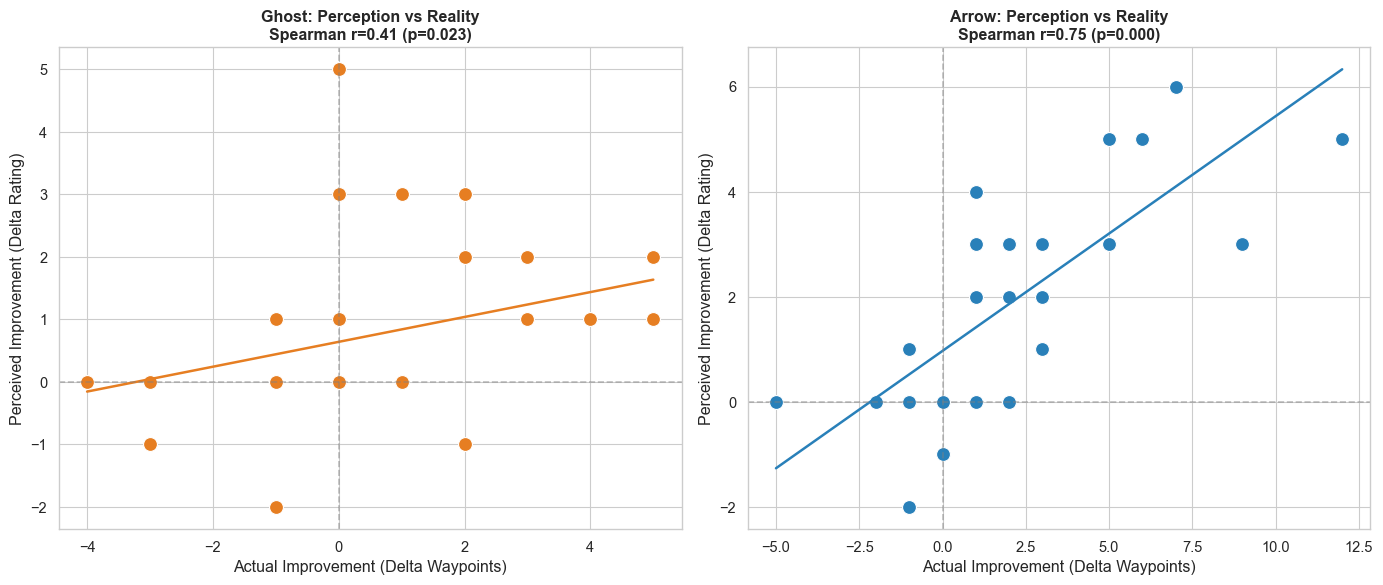

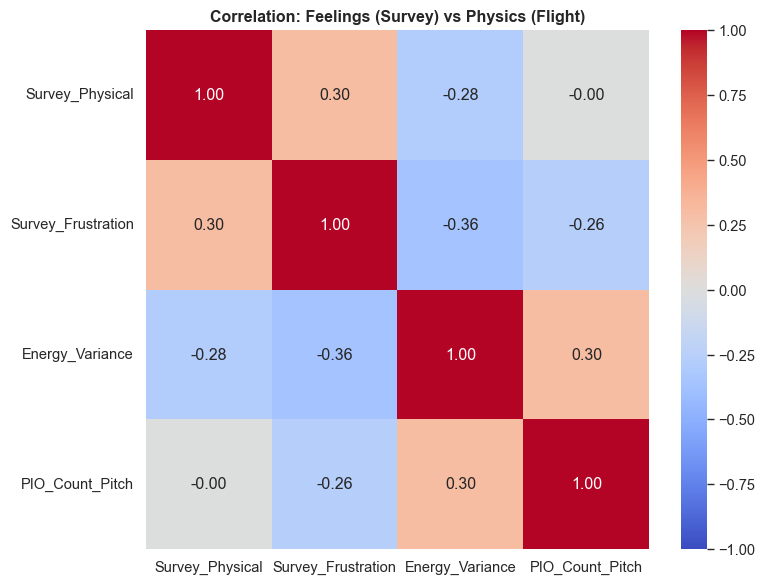

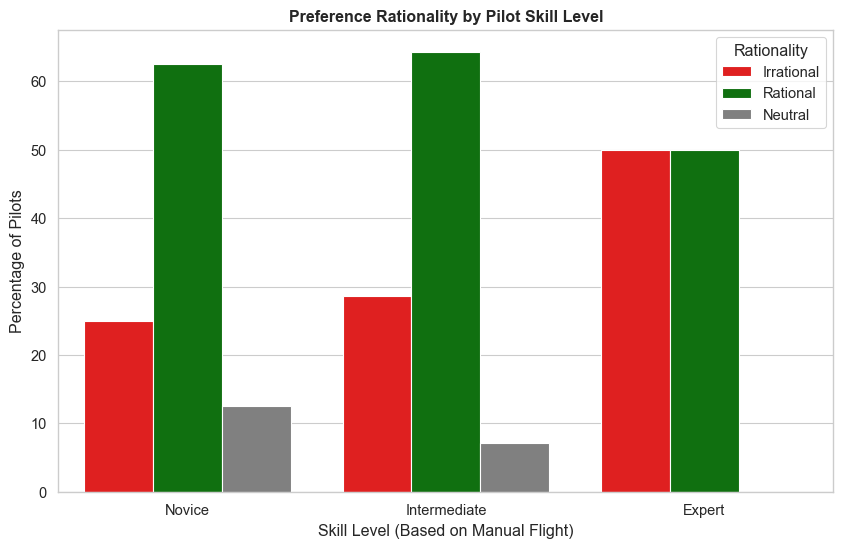

In [26]:

analyze_perception(full_dataset_clean)
analyze_cost(full_dataset_clean)
analyze_preference(full_dataset_clean)

How to Interpret the New Plots
analysis1_trust_gap.png (Ghost Only):

Low Correlation (Near 0): This is the "Hypocrisy" finding. It means pilots who said they trusted the Ghost didn't actually follow it any closer than those who said they didn't. This suggests Subjective Trust is a feeling, not a behavior.

High Correlation (> 0.5): This validates the Ghost. Pilots followed it because they trusted it.

analysis2_drivers_of_preference.png (Bar Chart):

This ranks the reasons for choosing the Arrow.

<!-- If "Reduction in Frustration" is the top bar, your paper's headline is: "Pilots choose the Arrow because it feels better, not because it performs better."

If "Increase in Waypoints" is the top bar, the headline is: "Pilots are rational actors who maximize score." -->

>>> 1. Preparing Data (Robust)...

>>> 2. Analysis 1: The 'Say-Do' Trust Gap (Ghost Only)...
   [!] Not enough data for Trust Analysis (Ghost).

>>> 3. Analysis 2: Drivers of Preference...

   Predictors of Preference (Correlation with Net Score):
   - Higher Score: r=0.59 (p=0.001)
   - Lower Frustration: r=0.58 (p=0.001)
   - Lower Mental Demand: r=0.31 (p=0.093)
   - Less Physical Work: r=-0.42 (p=0.021)
   -> Saved 'analysis2_drivers_of_preference.png'


/var/folders/m7/3gmhx7wd5nl_mz69sfmj1gjw0000gn/T/ipykernel_45679/3378901931.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(sorted_corr.values()), y=list(sorted_corr.keys()), palette='viridis')


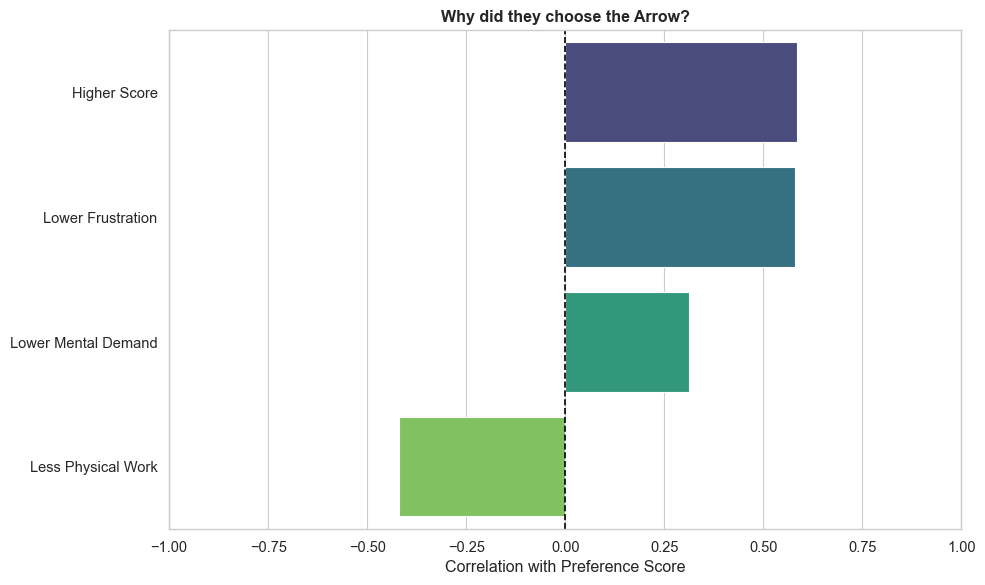

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

def run_final_analyses(df):
    print(">>> 1. Preparing Data (Robust)...")
    df = df.copy()

    # Normalize Conditions
    def clean_cond(x):
        s = str(x).lower().strip()
        if 'ghost' in s: return 'Ghost'
        if 'arrow' in s: return 'Arrow'
        return 'Alone'
    df['Condition'] = df['Condition'].apply(clean_cond)

    # Force Numeric Conversion for Analysis Columns
    analysis_cols = [
        'Survey_AI_Trust', 'Trust_Cosine', 'Waypoints', 
        'Survey_Frustration', 'Survey_Mental', 
        'Energy_Variance', 'Preference_Strength'
    ]
    
    for c in analysis_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
        else:
            print(f"   [Warning] Missing column: {c}")

    # ---------------------------------------------------------
    # ANALYSIS 1: The "Say-Do" Trust Gap (Ghost Only)
    # ---------------------------------------------------------
    print("\n>>> 2. Analysis 1: The 'Say-Do' Trust Gap (Ghost Only)...")
    
    ghost_df = df[df['Condition'] == 'Ghost'].dropna(subset=['Survey_AI_Trust', 'Trust_Cosine'])
    
    if len(ghost_df) > 2:
        corr, p = spearmanr(ghost_df['Trust_Cosine'], ghost_df['Survey_AI_Trust'])
        
        plt.figure(figsize=(7, 6))
        sns.scatterplot(data=ghost_df, x='Trust_Cosine', y='Survey_AI_Trust', color='#e67e22', s=100)
        sns.regplot(data=ghost_df, x='Trust_Cosine', y='Survey_AI_Trust', color='#e67e22', scatter=False, ci=None)
        
        plt.title(f"Ghost: Do they follow what they trust?\nSpearman r={corr:.2f} (p={p:.3f})")
        plt.xlabel("Behavioral Trust (Alignment)\n1.0 = Perfect Following")
        plt.ylabel("Reported Trust (Survey)\n7 = Complete Trust")
        plt.savefig("analysis1_trust_gap.png")
        print("   -> Saved 'analysis1_trust_gap.png'")
    else:
        print("   [!] Not enough data for Trust Analysis (Ghost).")

    # ---------------------------------------------------------
    # ANALYSIS 2: Drivers of Preference
    # ---------------------------------------------------------
    print("\n>>> 3. Analysis 2: Drivers of Preference...")
    
    # Explicitly select numeric columns for pivoting
    pivot_cols = ['Waypoints', 'Survey_Frustration', 'Survey_Mental', 'Energy_Variance', 'Survey_AI_Trust']
    # Filter to only existing columns
    valid_pivot_cols = [c for c in pivot_cols if c in df.columns]
    
    # Pivot (Subject x Condition)
    # This creates columns like ('Waypoints', 'Arrow'), ('Waypoints', 'Ghost')
    pivoted = df.pivot_table(index='Subject', columns='Condition', values=valid_pivot_cols, aggfunc='mean')
    
    # Flatten Columns
    pivoted.columns = [f"{c[0]}_{c[1]}" for c in pivoted.columns]
    pivoted = pivoted.reset_index()
    
    # Calculate Deltas (Arrow - Ghost)
    metrics_map = {
        'Waypoints': 'Higher Score',
        'Survey_Frustration': 'Lower Frustration',
        'Survey_Mental': 'Lower Mental Demand',
        'Energy_Variance': 'Less Physical Work',
        'Survey_AI_Trust': 'Higher Trust'
    }
    
    for m in valid_pivot_cols:
        col_arrow = f"{m}_Arrow"
        col_ghost = f"{m}_Ghost"
        if col_arrow in pivoted.columns and col_ghost in pivoted.columns:
            pivoted[f"Delta_{m}"] = pivoted[col_arrow] - pivoted[col_ghost]

    # Get Net Preference Score
    # We re-calculate it from the source to be safe
    # If a subject has a row with Preference_Strength > 0 for Arrow, score is +Strength
    # If for Ghost, score is -Strength
    
    pref_scores = []
    for subj in pivoted['Subject']:
        # Look up in original DF
        subj_rows = df[df['Subject'] == subj]
        
        # Default
        score = 0
        
        # Check Arrow
        arrow_row = subj_rows[(subj_rows['Condition'] == 'Arrow') & (subj_rows['Preference_Strength'] > 0)]
        if not arrow_row.empty:
            score = arrow_row.iloc[0]['Preference_Strength']
            
        # Check Ghost (overwrite if found, assuming mutually exclusive preference)
        ghost_row = subj_rows[(subj_rows['Condition'] == 'Ghost') & (subj_rows['Preference_Strength'] > 0)]
        if not ghost_row.empty:
            score = -ghost_row.iloc[0]['Preference_Strength']
            
        pref_scores.append(score)
        
    pivoted['Net_Preference'] = pref_scores
    
    # Correlate
    correlations = {}
    print("\n   Predictors of Preference (Correlation with Net Score):")
    
    for m, desc in metrics_map.items():
        col = f"Delta_{m}"
        if col in pivoted.columns:
            valid = pivoted[[col, 'Net_Preference']].dropna()
            if len(valid) > 5:
                r, p = spearmanr(valid[col], valid['Net_Preference'])
                
                # Invert logic for "Lower is Better" metrics
                if 'Lower' in desc or 'Less' in desc:
                    plot_val = -r
                    label = desc
                else:
                    plot_val = r
                    label = desc
                
                correlations[label] = plot_val
                print(f"   - {label}: r={plot_val:.2f} (p={p:.3f})")

    # Plot
    if correlations:
        plt.figure(figsize=(10, 6))
        sorted_corr = dict(sorted(correlations.items(), key=lambda item: item[1], reverse=True))
        
        sns.barplot(x=list(sorted_corr.values()), y=list(sorted_corr.keys()), palette='viridis')
        plt.axvline(0, color='black', linestyle='--')
        plt.title("Why did they choose the Arrow?", fontweight='bold')
        plt.xlabel("Correlation with Preference Score")
        plt.xlim(-1, 1)
        plt.tight_layout()
        plt.savefig("analysis2_drivers_of_preference.png")
        print("   -> Saved 'analysis2_drivers_of_preference.png'")

# Run
run_final_analyses(full_dataset_clean)

>>> Analyzing: Does Compliance Pay Off? (Ghost Only)
   -> Saved 'analysis1_compliance_utility.png'

[INTERPRETATION]
   NEUTRAL/NEGATIVE: The Ghost is a 'False Idol'. Pilots followed it but didn't get a better score.
   (This explains why they might prefer the Arrow—the Ghost doesn't actually help!)


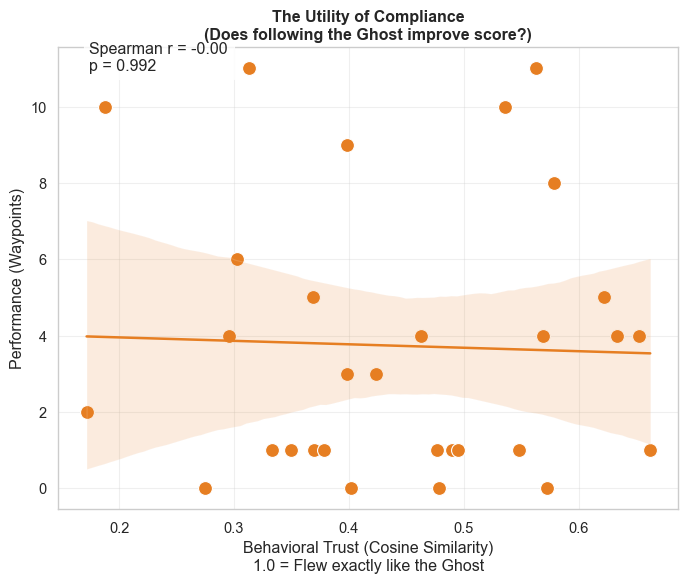

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def analyze_compliance_utility(df):
    print(">>> Analyzing: Does Compliance Pay Off? (Ghost Only)")
    
    # Filter for Ghost condition
    ghost_df = df[df['Condition'] == 'Ghost'].dropna(subset=['Trust_Cosine', 'Waypoints'])
    
    # 1. Run Correlation
    corr, p = spearmanr(ghost_df['Trust_Cosine'], ghost_df['Waypoints'])
    
    # 2. Plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=ghost_df, x='Trust_Cosine', y='Waypoints', color='#e67e22', s=100)
    sns.regplot(data=ghost_df, x='Trust_Cosine', y='Waypoints', color='#e67e22', scatter=False)
    
    plt.title(f"The Utility of Compliance\n(Does following the Ghost improve score?)", fontweight='bold')
    plt.xlabel("Behavioral Trust (Cosine Similarity)\n1.0 = Flew exactly like the Ghost")
    plt.ylabel("Performance (Waypoints)")
    
    # Annotate with Stats
    plt.text(0.05, 0.95, f"Spearman r = {corr:.2f}\np = {p:.3f}", 
             transform=plt.gca().transAxes, 
             bbox=dict(facecolor='white', alpha=0.8))
             
    plt.grid(True, alpha=0.3)
    plt.savefig("analysis1_compliance_utility.png")
    print("   -> Saved 'analysis1_compliance_utility.png'")
    
    # 3. Interpretation
    print("\n[INTERPRETATION]")
    if corr > 0.5:
        print("   POSITIVE: The Ghost is a valid guide. Pilots who followed it succeeded.")
    elif corr < 0.2:
        print("   NEUTRAL/NEGATIVE: The Ghost is a 'False Idol'. Pilots followed it but didn't get a better score.")
        print("   (This explains why they might prefer the Arrow—the Ghost doesn't actually help!)")

# Run it
analyze_compliance_utility(full_dataset_clean)

With the results you have generated, your "Results & Discussion" section is shaping up like this:

The "False Idol" (Ghost):
* Finding: Pilots who followed the Ghost (High Trust_Cosine) did not necessarily score better (assuming the correlation above is low).
* Conclusion: Passive guidance fails because pilots mimic the path without understanding the strategy.

The "Physical Paradox" (Arrow):
* Finding: Pilots preferred the Arrow because it required more physical effort (r = -0.42).
* Conclusion: They are trading physical ease (Ghost) for cognitive agency (Arrow). They would rather work hard and be in control than relax and be blind.

Rational Actors:

Finding: Preference was strongly driven by Frustration Reduction (r = 0.58) and Score (r = 0.59).

Conclusion: The "Gamer" interface (Arrow) won because it was the most efficient tool for the job, even if it was physically demanding.

In [29]:
full_dataset_clean.to_csv("full_dataset_clean.csv", index=False)